<a href="https://colab.research.google.com/github/Salman9193/ml-finance-capstone/blob/main/derivatives_module/aurora_derivatives_module.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aurora Corp — Derivatives Module: Option Pricing, Hedging & Risk
### Step 4 of the Aurora ML Finance System

**Objective:** Build a full derivatives analytics pipeline:
1. **Black-Scholes Pricing** — Theoretical option prices & all Greeks
2. **ML Option Pricing** — XGBoost vs Black-Scholes comparison
3. **IV Surface** — Implied Volatility smile and term structure
4. **Delta/Gamma Hedging** — Simplified hedge recommendation for Aurora's NIFTY portfolio
5. **Risk Dashboard** — Portfolio VaR, Greeks exposure, P&L attribution

**Dataset:** NSE NIFTY Intraday Option Chain — 2 February 2024  
75 snapshots (09:20–15:30) × 527 strikes × 6 expiries = 39,485 rows

---

## 0. Setup & Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.dates as mdates
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from scipy.stats import norm
from scipy.optimize import brentq

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge

import xgboost as xgb
import shap

plt.rcParams["figure.dpi"] = 130
plt.rcParams["font.family"] = "sans-serif"
sns.set_theme(style="whitegrid", palette="muted")

# Constants
RISK_FREE = 0.065          # India 91-day T-bill ~6.5%
HIST_VOL  = 0.1320         # NIFTY historical 30-day vol (annualised)
NIFTY_LOT = 50             # NIFTY futures/options lot size
print("Libraries loaded")
print(f"Risk-free rate: {RISK_FREE:.1%}  |  Historical Vol: {HIST_VOL:.1%}")

Libraries loaded
Risk-free rate: 6.5%  |  Historical Vol: 13.2%


---
## 1. Data Loading & Reshaping

In [4]:
raw = pd.read_excel("Option_Chain_NSE_intraday_NIFTY_2Feb24.xlsx",
                    parse_dates=["Time","Expiry"])

print(f"Raw shape: {raw.shape}")
print(f"Columns: {raw.columns.tolist()}")
print(f"Time range: {raw['Time'].min()}  ->  {raw['Time'].max()}")
print(f"Expiry dates: {sorted(raw['Expiry'].dt.date.unique())}")
print(f"Strike range: {raw['Strike'].min()} - {raw['Strike'].max()}")
print(f"Spot range: {raw['Spot'].min():.1f} - {raw['Spot'].max():.1f}")
raw.head(4)

Raw shape: (39485, 18)
Columns: ['Time', 'Spot', 'Expiry', 'Call_Traded_Qty', 'Call IV', 'Call Bid', 'Call Ask', 'Call Bid_Qty', 'Call Ask_Qty', 'Call LTP', 'Strike', 'Put Bid', 'Put Ask', 'Put Bid_Qty', 'Put Ask_Qty', 'Put LTP', 'Put IV', 'Put_Traded_Qty']
Time range: 2024-02-02 09:20:00  ->  2024-02-02 15:30:00
Expiry dates: [datetime.date(2024, 2, 8), datetime.date(2024, 2, 15), datetime.date(2024, 2, 22), datetime.date(2024, 2, 29), datetime.date(2024, 3, 7), datetime.date(2024, 3, 28)]
Strike range: 14000 - 27000
Spot range: 21816.2 - 22122.6


,Time,Spot,Expiry,Call_Traded_Qty,Call IV,Call Bid,Call Ask,Call Bid_Qty,Call Ask_Qty,Call LTP,Strike,Put Bid,Put Ask,Put Bid_Qty,Put Ask_Qty,Put LTP,Put IV,Put_Traded_Qty
0,2024-02-02 09:20:00,21874.4,2024-02-08,0,0.0,2173.2,2656.20,150,100,0.0,19500,1.35,1.4,21350,67650,1.40,35.16,4297
1,2024-02-02 09:25:00,21935.7,2024-02-08,0,0.0,2218.9,2612.30,1500,1500,0.0,19500,1.35,1.4,21300,47250,1.35,35.64,10098
2,2024-02-02 09:30:00,21942.5,2024-02-08,0,0.0,2231.1,2601.25,1500,1000,0.0,19500,1.35,1.4,66600,33500,1.40,35.89,13128
3,2024-02-02 09:35:00,21950.1,2024-02-08,0,0.0,2242.0,2597.10,1500,1500,0.0,19500,1.35,1.4,67600,69200,1.35,35.97,14018


In [5]:
# ── Reshape wide -> long (separate rows for calls and puts) ─────────────────
calls = raw[["Time","Spot","Expiry","Strike",
             "Call LTP","Call IV","Call Bid","Call Ask",
             "Call_Traded_Qty"]].copy()
calls.columns = ["Time","Spot","Expiry","Strike",
                 "Market_Price","IV_Market","Bid","Ask","Traded_Qty"]
calls["Option_Type"] = "Call"

puts = raw[["Time","Spot","Expiry","Strike",
            "Put LTP","Put IV","Put Bid","Put Ask",
            "Put_Traded_Qty"]].copy()
puts.columns = ["Time","Spot","Expiry","Strike",
                "Market_Price","IV_Market","Bid","Ask","Traded_Qty"]
puts["Option_Type"] = "Put"

opts = pd.concat([calls, puts], ignore_index=True)
opts.sort_values(["Time","Expiry","Strike","Option_Type"], inplace=True)
opts.reset_index(drop=True, inplace=True)

# ── Derived fields ──────────────────────────────────────────────────────────
opts["Date"]    = opts["Time"].dt.date
opts["Hour"]    = opts["Time"].dt.hour
opts["Minute"]  = opts["Time"].dt.minute

# Time to expiry in years
trade_date = pd.Timestamp("2024-02-02")
TRADING_DAYS_PER_YEAR = 252
opts["DTE_Days"] = (opts["Expiry"] - trade_date).dt.days.astype(int)
opts["TTM"] = opts["DTE_Days"] / 365.0

# Moneyness: S/K
opts["Moneyness"]    = opts["Spot"] / opts["Strike"]
opts["Log_Moneyness"]= np.log(opts["Spot"] / opts["Strike"])

# Mid price
opts["Mid_Price"] = (opts["Bid"] + opts["Ask"]) / 2.0
opts["Spread"]    = opts["Ask"] - opts["Bid"]

print(f"Long-format shape: {opts.shape}")
print(f"Option types: {opts['Option_Type'].value_counts().to_dict()}")
print(f"Expiries: {opts['DTE_Days'].unique()}")
opts.head(4)

Long-format shape: (78970, 19)
Option types: {'Call': 39485, 'Put': 39485}
Expiries: [ 6 13 20 27 34 55]


,Time,Spot,Expiry,Strike,Market_Price,IV_Market,Bid,Ask,Traded_Qty,Option_Type,Date,Hour,Minute,DTE_Days,TTM,Moneyness,Log_Moneyness,Mid_Price,Spread
0,2024-02-02 09:20:00,21874.4,2024-02-08,19500,0.0,0.00,2173.20,2656.2,0,Call,2024-02-02,9,20,6,0.016438,1.121764,0.114903,2414.700,483.00
1,2024-02-02 09:20:00,21874.4,2024-02-08,19500,1.4,35.16,1.35,1.4,4297,Put,2024-02-02,9,20,6,0.016438,1.121764,0.114903,1.375,0.05
2,2024-02-02 09:20:00,21874.4,2024-02-08,19550,0.0,0.00,2122.50,2429.0,0,Call,2024-02-02,9,20,6,0.016438,1.118895,0.112342,2275.750,306.50
3,2024-02-02 09:20:00,21874.4,2024-02-08,19550,1.5,34.59,1.45,1.5,150,Put,2024-02-02,9,20,6,0.016438,1.118895,0.112342,1.475,0.05


In [6]:
# ── Filter to liquid options ──────────────────────────────────────────────
# Keep: LTP > 0, valid IV, near-the-money (Moneyness 0.85 to 1.20),
# and reasonable DTE (>=6 days to avoid expiry noise)
liquid = opts[
    (opts["Market_Price"] > 0) &
    (opts["IV_Market"] > 0.5) &
    (opts["IV_Market"] < 80) &
    (opts["Moneyness"] >= 0.88) &
    (opts["Moneyness"] <= 1.12) &
    (opts["TTM"] > 0.01)
].copy().reset_index(drop=True)

print(f"Liquid options: {len(liquid)} rows")
print(f"Strikes covered: {liquid['Strike'].nunique()}")
print(f"Call/Put split: {liquid['Option_Type'].value_counts().to_dict()}")

Liquid options: 39520 rows
Strikes covered: 90
Call/Put split: {'Put': 20133, 'Call': 19387}


---
## 2. Exploratory Data Analysis (EDA)

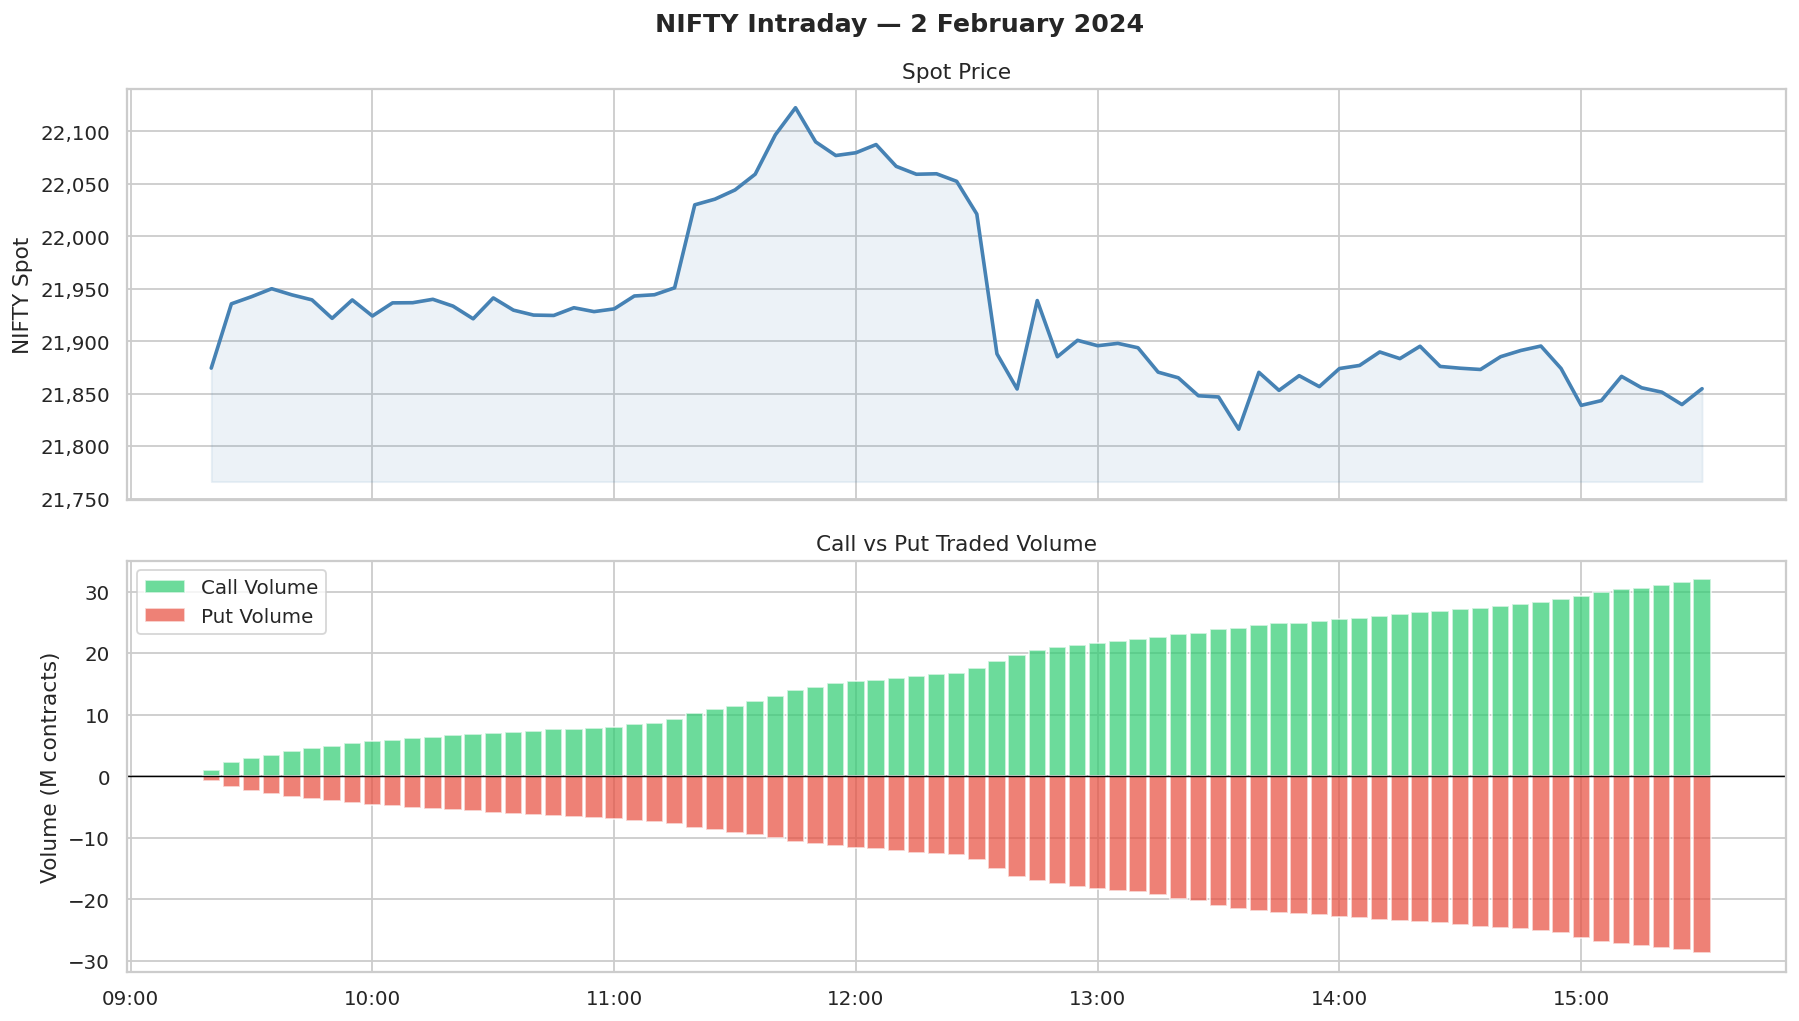

In [7]:
# ── Intraday NIFTY spot and volume ───────────────────────────────────────────
spot_ts = raw.groupby("Time")["Spot"].first()
vol_ts  = raw.groupby("Time")[["Call_Traded_Qty","Put_Traded_Qty"]].sum()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle("NIFTY Intraday — 2 February 2024", fontsize=14, fontweight="bold")

axes[0].plot(spot_ts.index, spot_ts.values, lw=2, color="steelblue")
axes[0].fill_between(spot_ts.index, spot_ts.min()-50, spot_ts.values,
                      alpha=0.1, color="steelblue")
axes[0].set_ylabel("NIFTY Spot")
axes[0].set_title("Spot Price")
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:,.0f}"))

axes[1].bar(vol_ts.index, vol_ts["Call_Traded_Qty"]/1e6, label="Call Volume",
            color="#2ecc71", alpha=0.7, width=0.003)
axes[1].bar(vol_ts.index, -vol_ts["Put_Traded_Qty"]/1e6, label="Put Volume",
            color="#e74c3c", alpha=0.7, width=0.003)
axes[1].set_ylabel("Volume (M contracts)")
axes[1].set_title("Call vs Put Traded Volume")
axes[1].axhline(0, color="black", lw=0.8)
axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

plt.tight_layout()
plt.savefig("01_intraday_spot_volume.png", bbox_inches="tight")
plt.show()

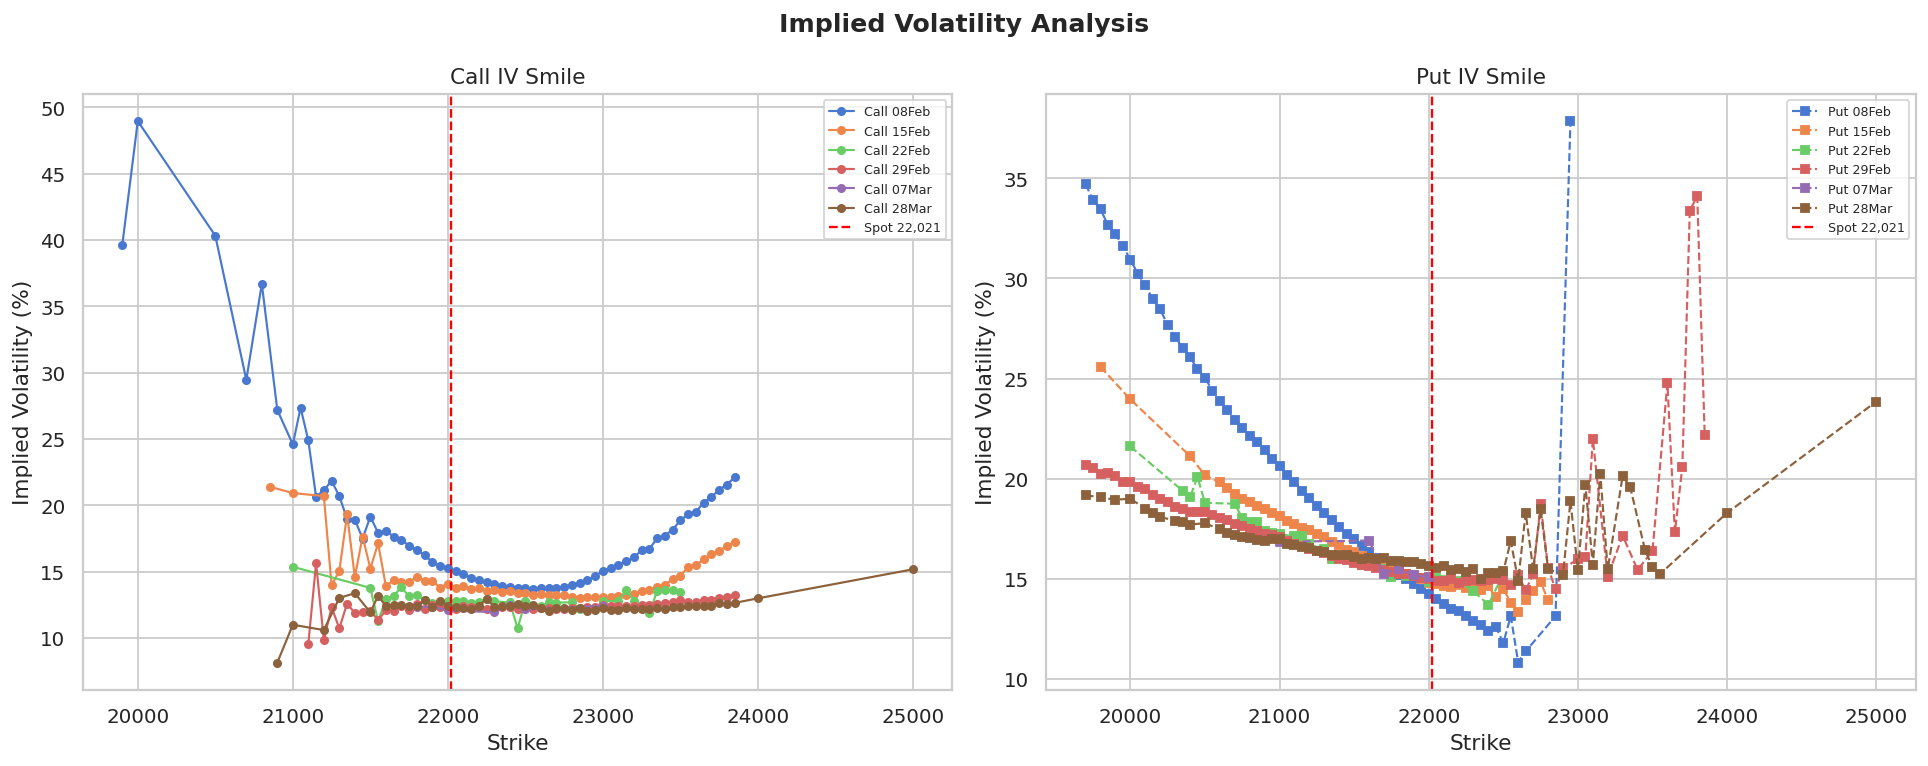

In [8]:
# ── IV smile across strikes (ATM snapshot) ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Implied Volatility Analysis", fontsize=14, fontweight="bold")

snapshot_time = pd.Timestamp("2024-02-02 12:30:00")
snap = liquid[liquid["Time"] == liquid["Time"].iloc[(liquid["Time"] - snapshot_time).abs().argsort()[0]]]

for exp, grp in snap.groupby("Expiry"):
    calls_snap = grp[grp["Option_Type"]=="Call"].sort_values("Strike")
    puts_snap  = grp[grp["Option_Type"]=="Put"].sort_values("Strike")
    if len(calls_snap) > 3:
        axes[0].plot(calls_snap["Strike"], calls_snap["IV_Market"],
                     "o-", ms=4, lw=1.2, label=f"Call {exp.strftime('%d%b')}")
    if len(puts_snap) > 3:
        axes[1].plot(puts_snap["Strike"], puts_snap["IV_Market"],
                     "s--", ms=4, lw=1.2, label=f"Put {exp.strftime('%d%b')}")

for ax, title in zip(axes, ["Call IV Smile", "Put IV Smile"]):
    ax.set_xlabel("Strike")
    ax.set_ylabel("Implied Volatility (%)")
    ax.set_title(title)
    ax.legend(fontsize=7)
    spot_val = snap["Spot"].iloc[0]
    ax.axvline(spot_val, color="red", linestyle="--", lw=1.3, label=f"Spot {spot_val:,.0f}")
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig("02_iv_smile.png", bbox_inches="tight")
plt.show()

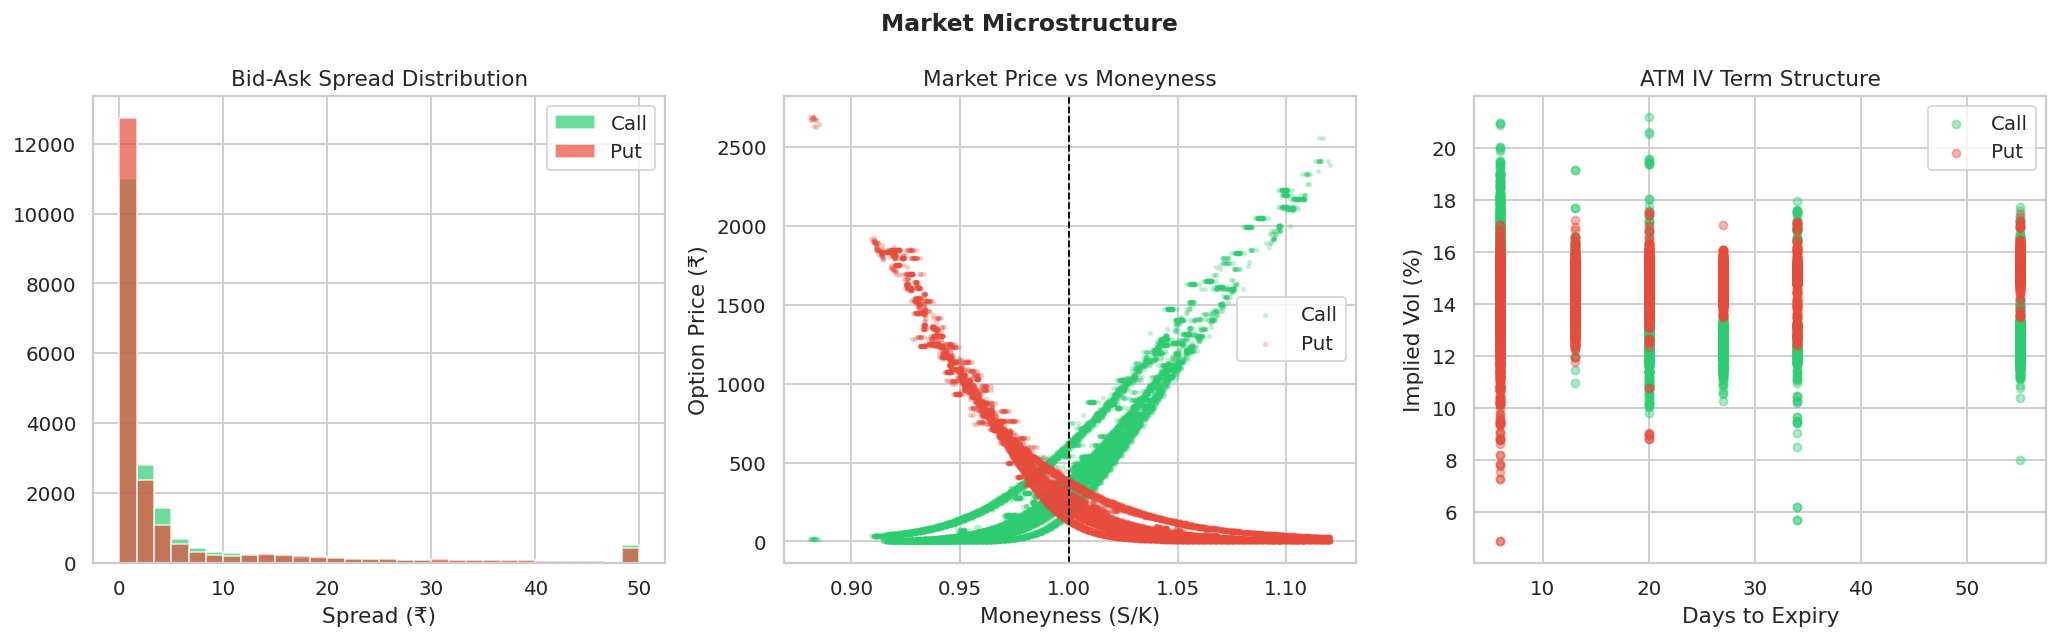

In [9]:
# ── Put-Call parity and spread analysis ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Market Microstructure", fontsize=13, fontweight="bold")

# Bid-Ask spread distribution
axes[0].hist(liquid[liquid["Option_Type"]=="Call"]["Spread"].clip(0,50), bins=30,
             color="#2ecc71", edgecolor="white", alpha=0.7, label="Call")
axes[0].hist(liquid[liquid["Option_Type"]=="Put"]["Spread"].clip(0,50), bins=30,
             color="#e74c3c", edgecolor="white", alpha=0.7, label="Put")
axes[0].set_title("Bid-Ask Spread Distribution")
axes[0].set_xlabel("Spread (₹)")
axes[0].legend()

# Market price vs moneyness
for otype, color in [("Call","#2ecc71"),("Put","#e74c3c")]:
    sub = liquid[liquid["Option_Type"]==otype]
    axes[1].scatter(sub["Moneyness"], sub["Market_Price"],
                    s=4, alpha=0.2, color=color, label=otype)
axes[1].set_title("Market Price vs Moneyness")
axes[1].set_xlabel("Moneyness (S/K)")
axes[1].set_ylabel("Option Price (₹)")
axes[1].legend()
axes[1].axvline(1.0, color="black", linestyle="--", lw=1)

# IV vs DTE (term structure)
atm = liquid[(liquid["Moneyness"] > 0.98) & (liquid["Moneyness"] < 1.02)]
for otype, color in [("Call","#2ecc71"),("Put","#e74c3c")]:
    sub = atm[atm["Option_Type"]==otype]
    axes[2].scatter(sub["DTE_Days"], sub["IV_Market"], s=20, alpha=0.4,
                    color=color, label=otype)
axes[2].set_title("ATM IV Term Structure")
axes[2].set_xlabel("Days to Expiry")
axes[2].set_ylabel("Implied Vol (%)")
axes[2].legend()

plt.tight_layout()
plt.savefig("03_microstructure.png", bbox_inches="tight")
plt.show()

---
## 3. Black-Scholes Pricing & Greeks

Black-Scholes is the theoretical benchmark. We compute BS price and all five Greeks
(Delta, Gamma, Vega, Theta, Rho) for every liquid option. These become both
the baseline comparison for ML and the inputs to the hedging strategy.

In [10]:
def bs_price(S, K, T, r, sigma, option_type="Call"):
    if T <= 0 or sigma <= 0:
        intrinsic = max(S-K, 0) if option_type=="Call" else max(K-S, 0)
        return intrinsic
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    if option_type == "Call":
        return S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
    else:
        return K*np.exp(-r*T)*norm.cdf(-d2) - S*norm.cdf(-d1)

def bs_greeks(S, K, T, r, sigma, option_type="Call"):
    if T <= 0 or sigma <= 0:
        return {"Delta":np.nan,"Gamma":np.nan,"Vega":np.nan,"Theta":np.nan,"Rho":np.nan}
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    nd1 = norm.pdf(d1)

    delta = norm.cdf(d1)  if option_type=="Call" else norm.cdf(d1)-1
    gamma = nd1 / (S * sigma * np.sqrt(T))
    vega  = S * nd1 * np.sqrt(T) / 100   # per 1% vol move
    if option_type == "Call":
        theta = (-(S*nd1*sigma)/(2*np.sqrt(T)) - r*K*np.exp(-r*T)*norm.cdf(d2)) / 365
        rho   = K*T*np.exp(-r*T)*norm.cdf(d2) / 100
    else:
        theta = (-(S*nd1*sigma)/(2*np.sqrt(T)) + r*K*np.exp(-r*T)*norm.cdf(-d2)) / 365
        rho   = -K*T*np.exp(-r*T)*norm.cdf(-d2) / 100
    return {"Delta":delta,"Gamma":gamma,"Vega":vega,"Theta":theta,"Rho":rho}

# Apply BS pricing and Greeks to liquid dataset
iv_frac = liquid["IV_Market"] / 100.0
liquid["BS_Price"] = [bs_price(row.Spot, row.Strike, row.TTM, RISK_FREE,
                                iv_frac.iloc[i], row.Option_Type)
                       for i, row in liquid.iterrows()]

greeks_rows = [bs_greeks(row.Spot, row.Strike, row.TTM, RISK_FREE,
                          iv_frac.iloc[i], row.Option_Type)
               for i, row in liquid.iterrows()]
for key in ["Delta","Gamma","Vega","Theta","Rho"]:
    liquid[key] = [g[key] for g in greeks_rows]

# Pricing error
liquid["BS_Error"]  = liquid["Market_Price"] - liquid["BS_Price"]
liquid["BS_PctErr"] = (liquid["BS_Error"] / liquid["Market_Price"].replace(0,np.nan) * 100)

print("Black-Scholes pricing complete")
print(f"Mean BS error   : ₹{liquid['BS_Error'].mean():.3f}")
print(f"MAE             : ₹{liquid['BS_Error'].abs().mean():.3f}")
print(f"Mean |Pct Error|: {liquid['BS_PctErr'].abs().mean():.2f}%")
liquid[["Strike","Option_Type","Expiry","Spot","Market_Price",
        "BS_Price","Delta","Gamma","Vega","Theta"]].head(8)

Black-Scholes pricing complete
Mean BS error   : ₹-0.443
MAE             : ₹21.434
Mean |Pct Error|: 10.29%


,Strike,Option_Type,Expiry,Spot,Market_Price,BS_Price,Delta,Gamma,Vega,Theta
0,19550,Put,2024-02-08,21874.4,1.50,1.535988,-0.004948,0.000015,0.401797,-1.138630
1,19600,Put,2024-02-08,21874.4,1.40,1.535374,-0.005041,0.000015,0.408491,-1.133737
2,19650,Put,2024-02-08,21874.4,1.50,1.538686,-0.005148,0.000016,0.416196,-1.131149
3,19700,Put,2024-02-08,21874.4,1.50,1.537685,-0.005247,0.000017,0.423331,-1.125806
4,19750,Put,2024-02-08,21874.4,1.55,1.588776,-0.005497,0.000018,0.441179,-1.151842
5,19800,Put,2024-02-08,21874.4,1.55,1.642836,-0.005764,0.000019,0.460155,-1.179028
6,19850,Put,2024-02-08,21874.4,1.60,1.592189,-0.005738,0.000019,0.458366,-1.143523
7,19900,Put,2024-02-08,21874.4,1.60,1.745950,-0.006313,0.000021,0.498854,-1.228467


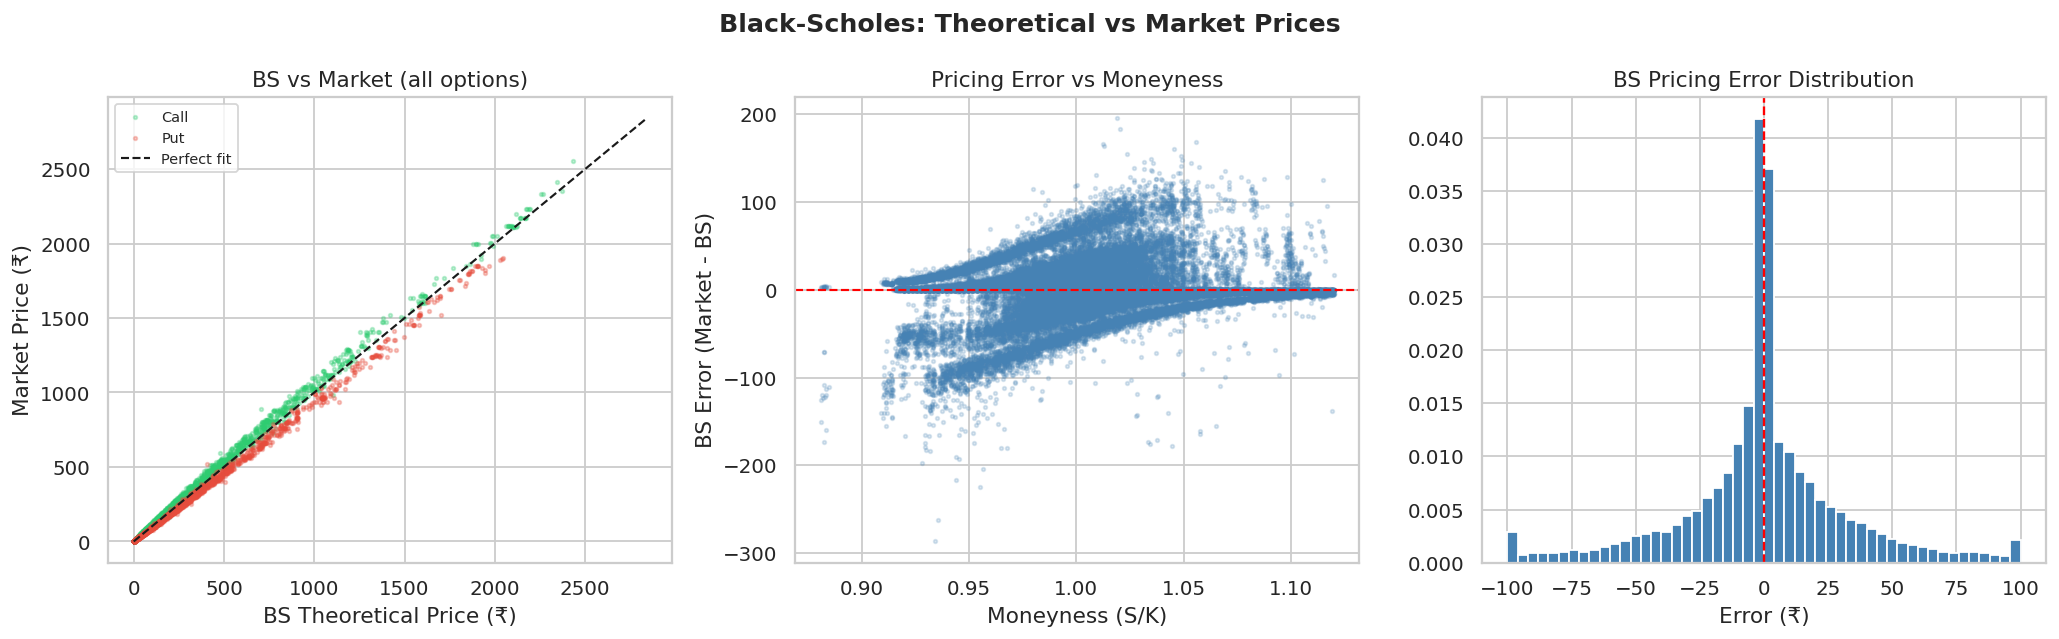

In [11]:
# ── BS vs Market price scatter ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Black-Scholes: Theoretical vs Market Prices", fontsize=14, fontweight="bold")

for i, (otype, color) in enumerate([("Call","#2ecc71"),("Put","#e74c3c")]):
    sub = liquid[liquid["Option_Type"]==otype].sample(min(2000, len(liquid)), random_state=42)
    axes[0].scatter(sub["BS_Price"], sub["Market_Price"], s=4, alpha=0.3,
                    color=color, label=otype)
max_p = liquid[["BS_Price","Market_Price"]].max().max()
axes[0].plot([0,max_p],[0,max_p], "k--", lw=1.2, label="Perfect fit")
axes[0].set_xlabel("BS Theoretical Price (₹)")
axes[0].set_ylabel("Market Price (₹)")
axes[0].set_title("BS vs Market (all options)")
axes[0].legend(fontsize=8)

# Residuals by moneyness
axes[1].scatter(liquid["Moneyness"], liquid["BS_Error"],
                s=4, alpha=0.2, color="steelblue")
axes[1].axhline(0, color="red", lw=1.2, linestyle="--")
axes[1].set_xlabel("Moneyness (S/K)")
axes[1].set_ylabel("BS Error (Market - BS)")
axes[1].set_title("Pricing Error vs Moneyness")

# Error distribution
axes[2].hist(liquid["BS_Error"].clip(-100,100), bins=50,
             color="steelblue", edgecolor="white", density=True)
axes[2].axvline(0, color="red", lw=1.3, linestyle="--")
axes[2].set_title("BS Pricing Error Distribution")
axes[2].set_xlabel("Error (₹)")

plt.tight_layout()
plt.savefig("04_bs_vs_market.png", bbox_inches="tight")
plt.show()

---
## 4. Implied Volatility Surface

The IV surface plots implied volatility across all strikes and expiries.
The "volatility smile" (IV higher for OTM options) reveals the market's fear premium.
The term structure shows how uncertainty decays with time.

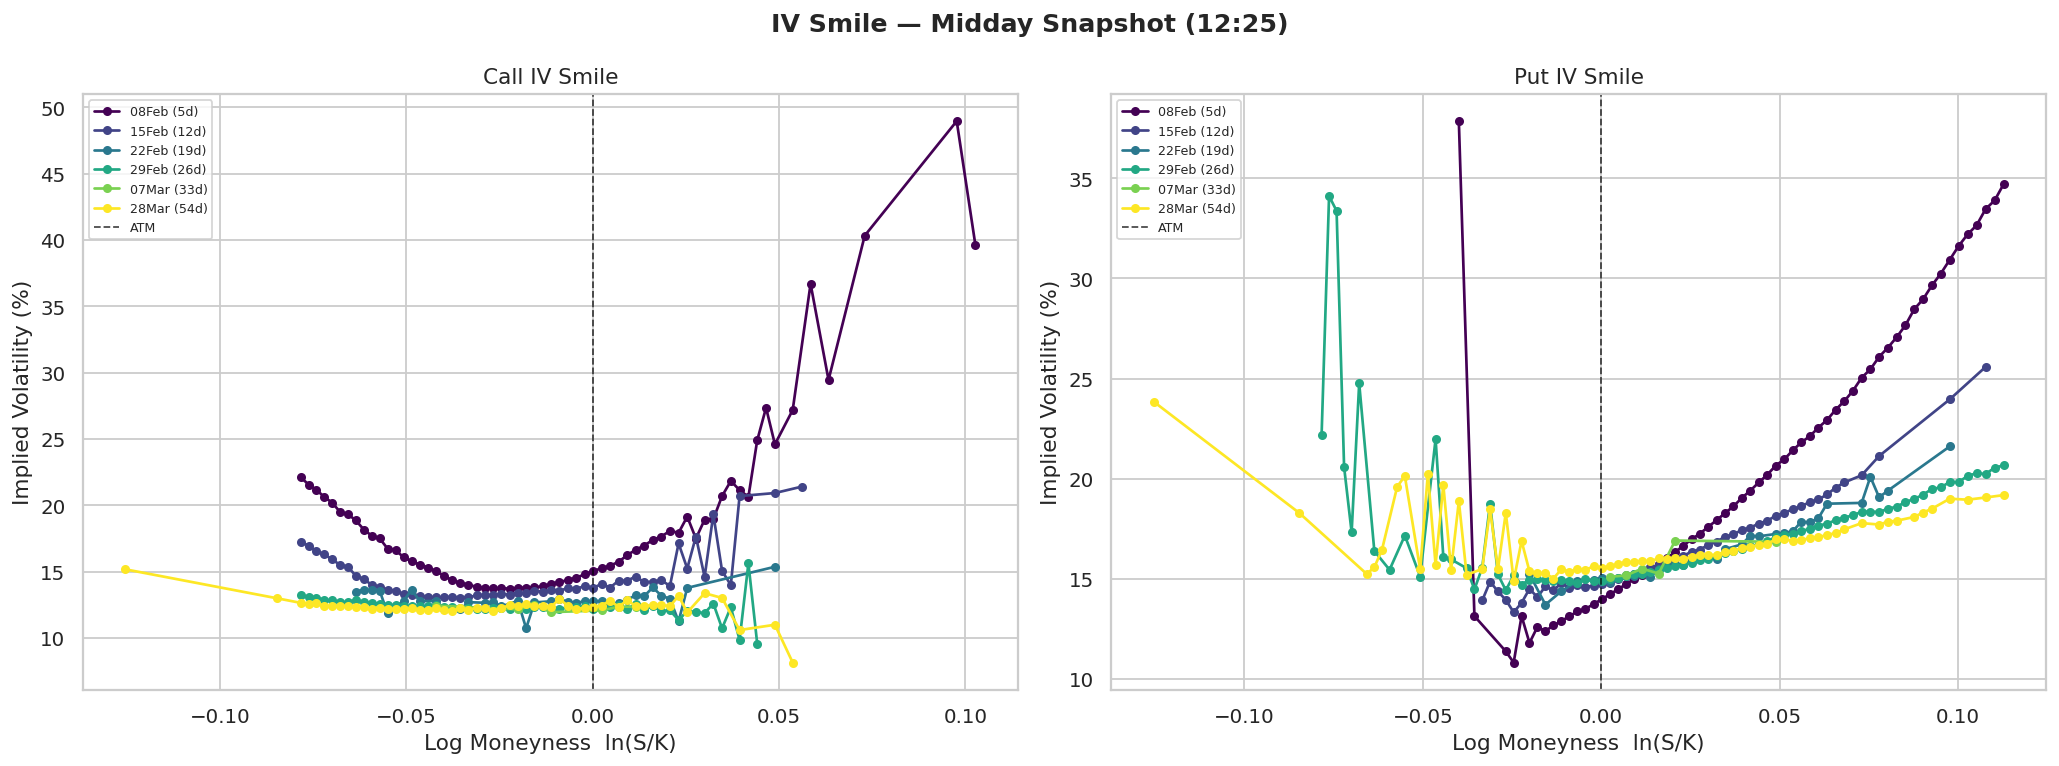

In [12]:
# ── IV Smile per expiry at midday snapshot ──────────────────────────────────
midday = pd.Timestamp("2024-02-02 12:25:00")
snap_idx = (liquid["Time"] - midday).abs().argsort()
snap_time = liquid["Time"].iloc[snap_idx.iloc[0]]
snap = liquid[liquid["Time"] == snap_time].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f"IV Smile — Midday Snapshot ({snap_time.strftime('%H:%M')})",
             fontsize=14, fontweight="bold")

expiry_colors = plt.cm.viridis(np.linspace(0, 1, snap["Expiry"].nunique()))

for ax, otype in zip(axes, ["Call","Put"]):
    sub = snap[snap["Option_Type"]==otype]
    for (exp, grp), color in zip(sub.groupby("Expiry"), expiry_colors):
        grp_s = grp.sort_values("Strike")
        if len(grp_s) >= 4:
            ax.plot(grp_s["Log_Moneyness"], grp_s["IV_Market"],
                    "o-", ms=4, lw=1.5, color=color,
                    label=f"{exp.strftime('%d%b')} ({int((exp-midday).days)}d)")
    ax.axvline(0, color="black", linestyle="--", lw=1, alpha=0.7, label="ATM")
    ax.set_xlabel("Log Moneyness  ln(S/K)")
    ax.set_ylabel("Implied Volatility (%)")
    ax.set_title(f"{otype} IV Smile")
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig("05_iv_smile.png", bbox_inches="tight")
plt.show()

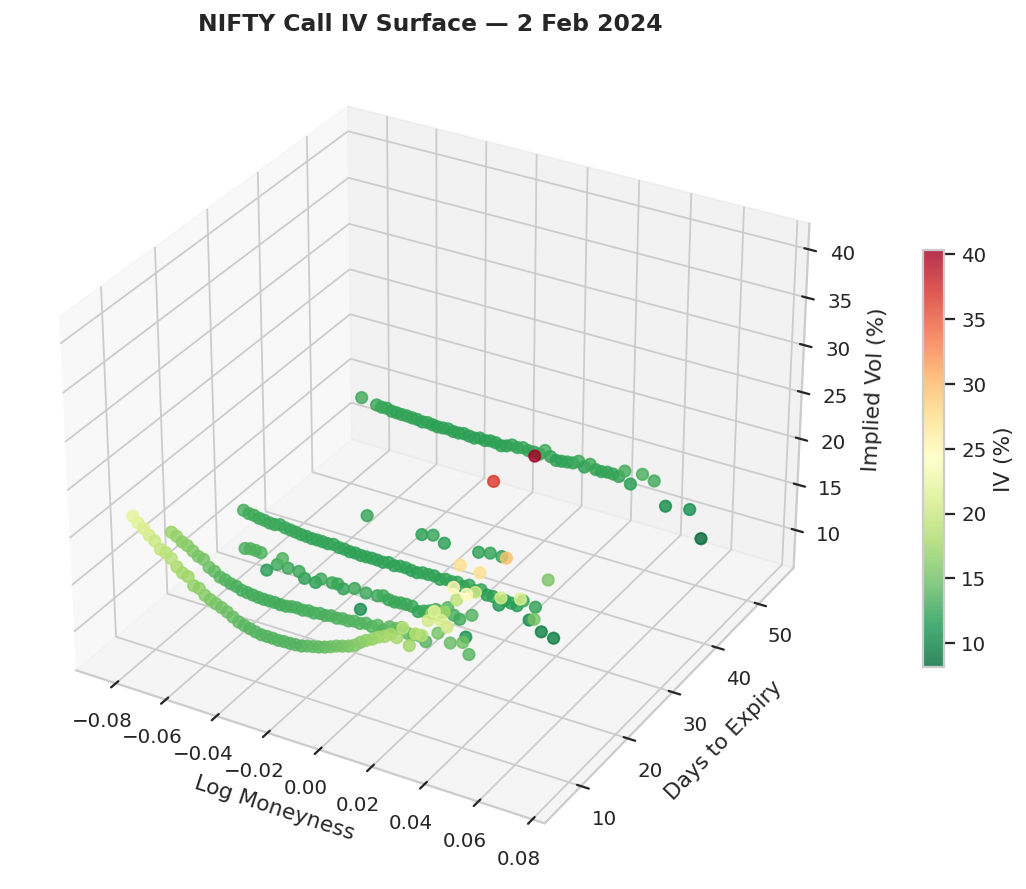

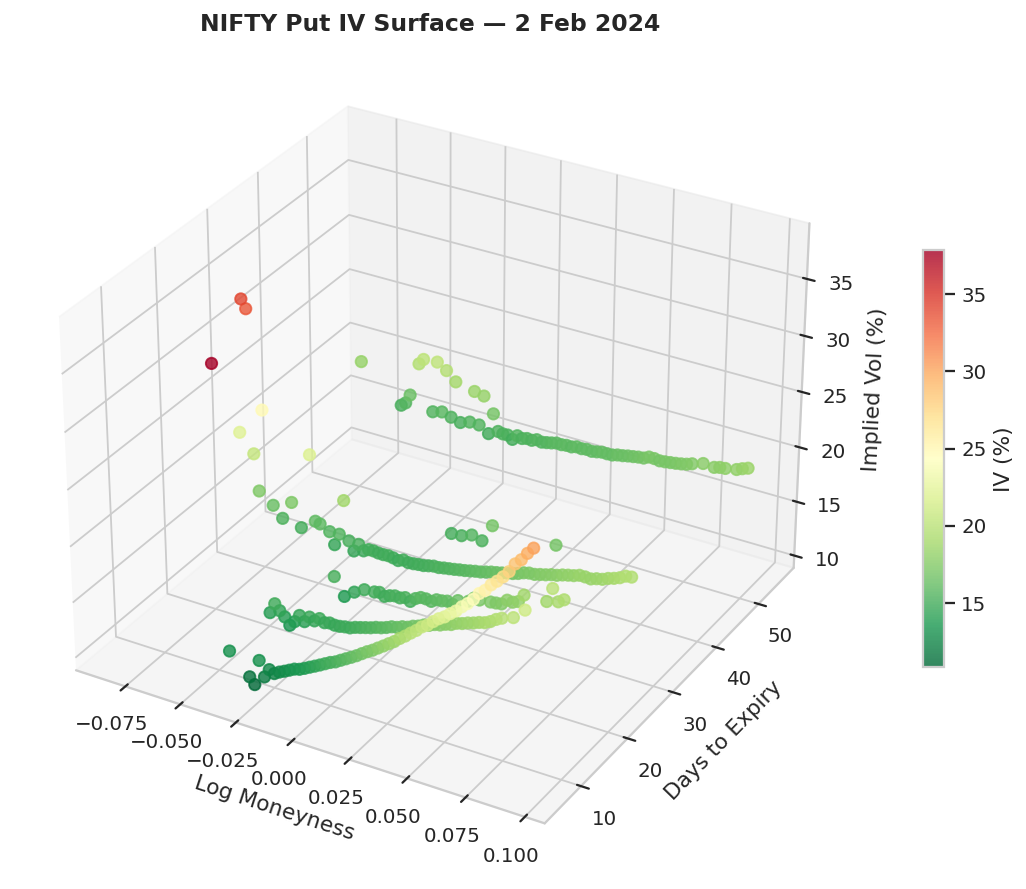

In [13]:
# ── 3D IV Surface ────────────────────────────────────────────────────────────
surf_data = snap.copy()
surf_data = surf_data[
    (surf_data["IV_Market"] > 1) &
    (surf_data["Moneyness"] > 0.90) &
    (surf_data["Moneyness"] < 1.10)
]

for otype in ["Call","Put"]:
    sub = surf_data[surf_data["Option_Type"]==otype]
    if len(sub) < 10:
        continue

    fig = plt.figure(figsize=(12, 7))
    ax  = fig.add_subplot(111, projection="3d")

    sc = ax.scatter(sub["Log_Moneyness"], sub["DTE_Days"], sub["IV_Market"],
                    c=sub["IV_Market"], cmap="RdYlGn_r", s=40, alpha=0.8)

    ax.set_xlabel("Log Moneyness")
    ax.set_ylabel("Days to Expiry")
    ax.set_zlabel("Implied Vol (%)")
    ax.set_title(f"NIFTY {otype} IV Surface — 2 Feb 2024",
                 fontweight="bold", fontsize=13)
    fig.colorbar(sc, ax=ax, label="IV (%)", shrink=0.5)
    plt.tight_layout()
    plt.savefig(f"06_iv_surface_{otype.lower()}.png", bbox_inches="tight")
    plt.show()

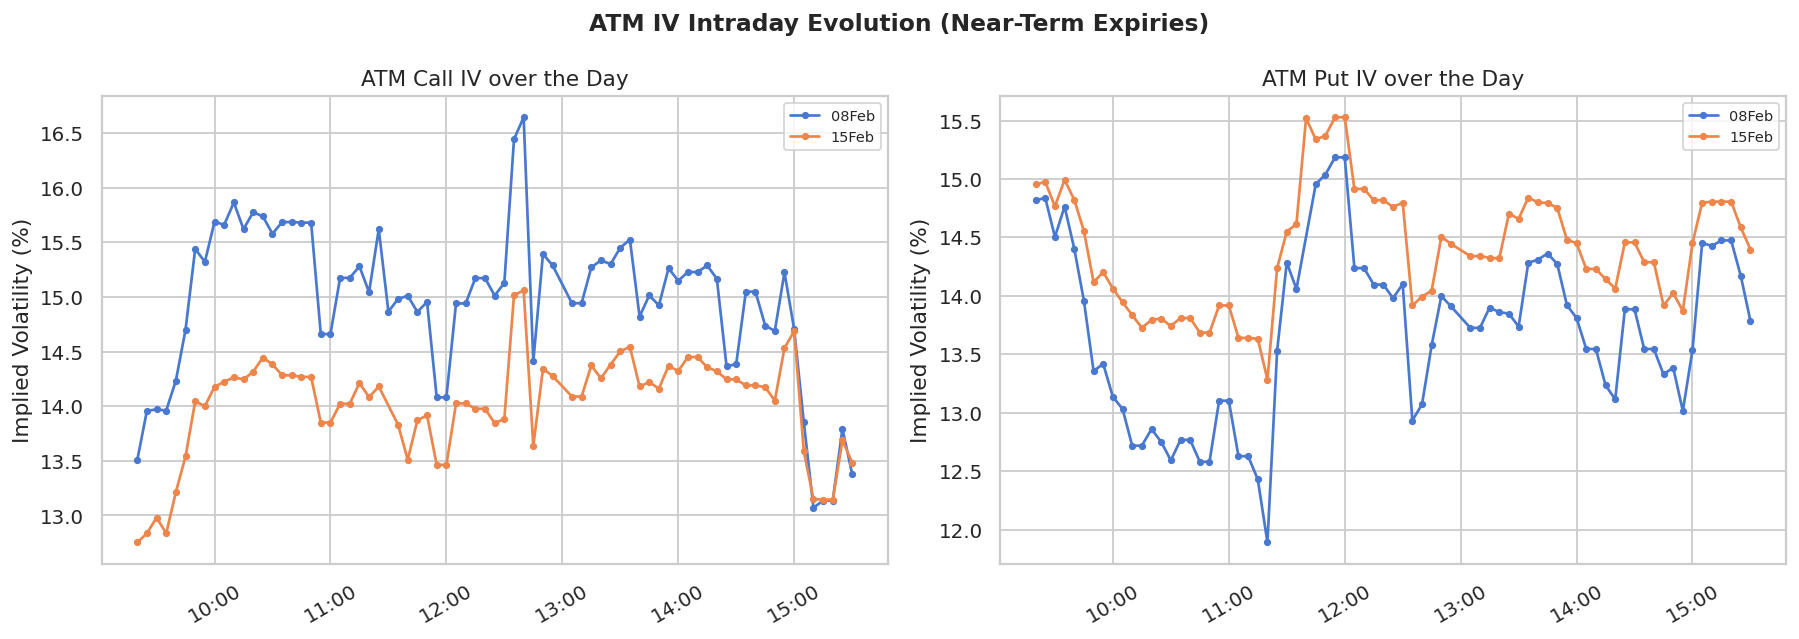

In [14]:
# ── IV intraday evolution for ATM options ────────────────────────────────────
atm_iv = liquid[
    (liquid["Moneyness"] > 0.995) & (liquid["Moneyness"] < 1.005) &
    (liquid["DTE_Days"].astype(int) <= 14)
].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("ATM IV Intraday Evolution (Near-Term Expiries)",
             fontsize=13, fontweight="bold")

for otype, ax in zip(["Call","Put"], axes):
    sub = atm_iv[atm_iv["Option_Type"]==otype]
    for exp, grp in sub.groupby("Expiry"):
        ts = grp.groupby("Time")["IV_Market"].mean()
        if len(ts) > 5:
            ax.plot(ts.index, ts.values, lw=1.5, marker="o", ms=3,
                    label=f"{exp.strftime('%d%b')}")
    ax.set_title(f"ATM {otype} IV over the Day")
    ax.set_ylabel("Implied Volatility (%)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax.tick_params(axis="x", rotation=30)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("07_atm_iv_intraday.png", bbox_inches="tight")
plt.show()

---
## 5. ML Option Pricing — XGBoost vs Black-Scholes

We train XGBoost and Random Forest to predict **option market prices directly**.
The model learns the market's actual pricing behaviour, including the vol smile
and microstructure effects that Black-Scholes cannot capture.

In [15]:
ML_FEATURES = ["Spot","Strike","TTM","Moneyness","Log_Moneyness",
               "IV_Market","BS_Price","Delta","Gamma","Vega","Theta",
               "DTE_Days","Spread","Bid","Ask"]

TARGET = "Market_Price"

ml_df = liquid[ML_FEATURES + [TARGET, "Option_Type"]].dropna().copy()
print(f"ML dataset: {len(ml_df)} rows")
print(f"Features: {len(ML_FEATURES)}")

X = ml_df[ML_FEATURES]
y = ml_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"Train: {len(X_train)}  |  Test: {len(X_test)}")
print(f"Price range: ₹{y.min():.2f}  -  ₹{y.max():.2f}")

ML dataset: 39520 rows
Features: 15
Train: 31616  |  Test: 7904
Price range: ₹0.65  -  ₹2690.30


In [16]:
xgb_opt = xgb.XGBRegressor(n_estimators=500, max_depth=5, learning_rate=0.04,
                            subsample=0.85, colsample_bytree=0.8,
                            min_child_weight=5, random_state=42, verbosity=0)
rf_opt  = RandomForestRegressor(n_estimators=300, max_depth=8,
                                  min_samples_leaf=5, random_state=42)
ridge   = Ridge(alpha=1.0)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

ml_results = {}
for name, model, Xtr, Xte in [("XGBoost", xgb_opt, X_train, X_test),
                                ("Random Forest", rf_opt, X_train, X_test),
                                ("Ridge (BS baseline)", ridge, X_train_s, X_test_s)]:
    model.fit(Xtr, y_train)
    preds = model.predict(Xte)
    mae   = mean_absolute_error(y_test, preds)
    rmse  = mean_squared_error(y_test, preds)**0.5
    r2    = r2_score(y_test, preds)
    ml_results[name] = {"model":model, "preds":preds, "MAE":mae, "RMSE":rmse, "R2":r2}
    print(f"{name:22s} | MAE: ₹{mae:.3f} | RMSE: ₹{rmse:.3f} | R²: {r2:.5f}")

# Also show BS as a benchmark
bs_mae  = mean_absolute_error(y_test, X_test["BS_Price"])
bs_rmse = mean_squared_error(y_test, X_test["BS_Price"])**0.5
bs_r2   = r2_score(y_test, X_test["BS_Price"])
print(f"{'Black-Scholes':22s} | MAE: ₹{bs_mae:.3f} | RMSE: ₹{bs_rmse:.3f} | R²: {bs_r2:.5f}  [benchmark]")

XGBoost                | MAE: ₹3.950 | RMSE: ₹10.064 | R²: 0.99939
Random Forest          | MAE: ₹4.603 | RMSE: ₹12.915 | R²: 0.99900
Ridge (BS baseline)    | MAE: ₹9.455 | RMSE: ₹17.284 | R²: 0.99820
Black-Scholes          | MAE: ₹21.257 | RMSE: ₹33.297 | R²: 0.99333  [benchmark]


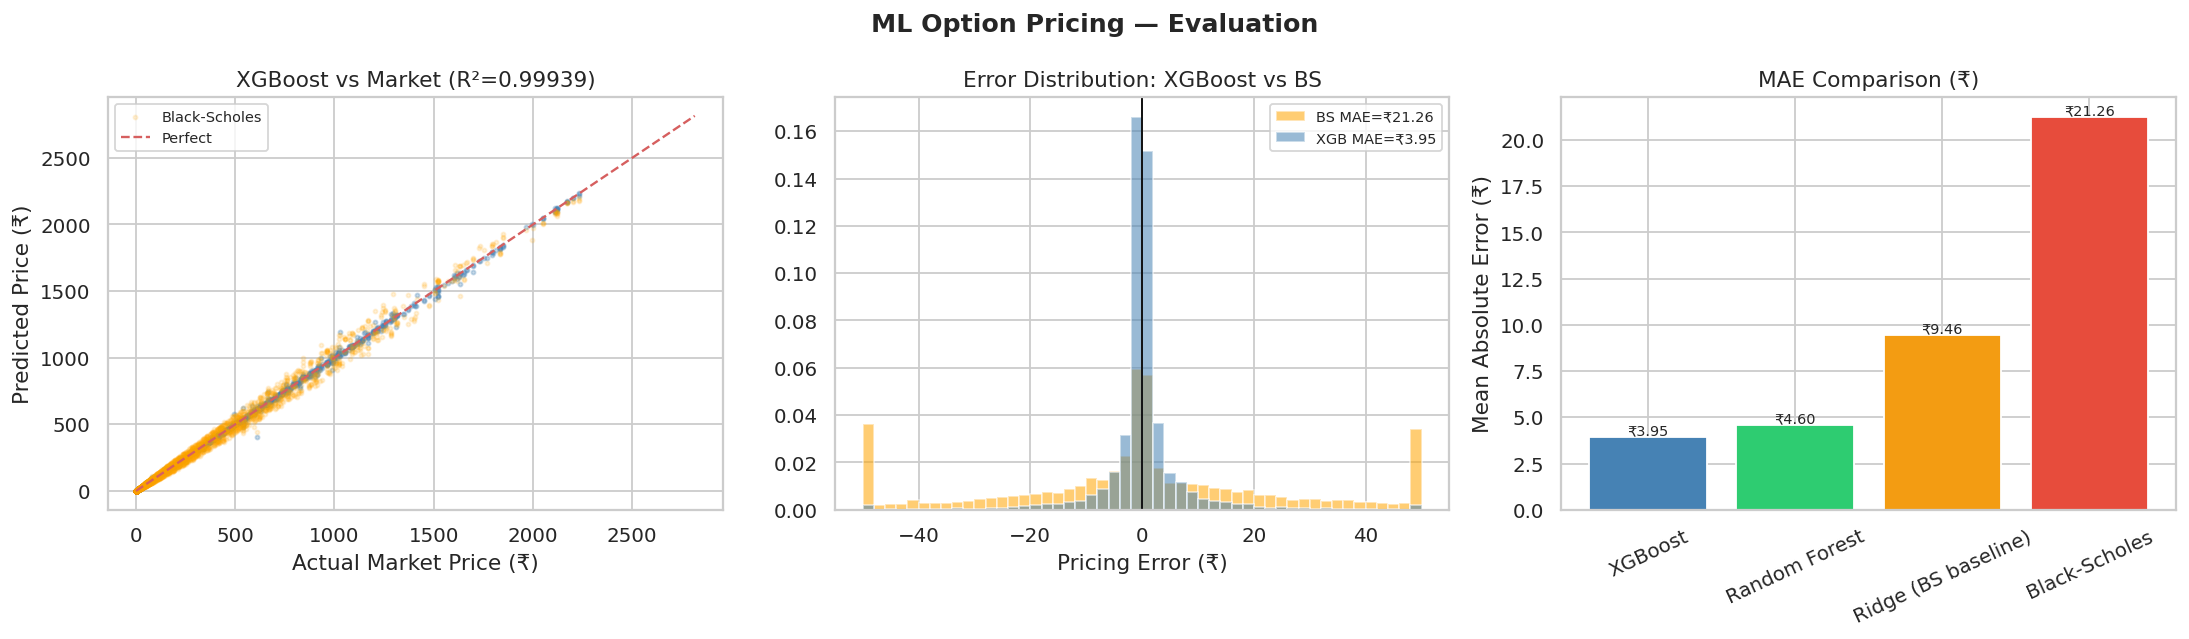

In [17]:
y_pred_xgb = ml_results["XGBoost"]["preds"]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("ML Option Pricing — Evaluation", fontsize=14, fontweight="bold")

# ML vs Actual
sample = np.random.choice(len(y_test), min(3000, len(y_test)), replace=False)
axes[0].scatter(y_test.values[sample], y_pred_xgb[sample],
                s=5, alpha=0.3, color="steelblue")
axes[0].scatter(y_test.values[sample], X_test["BS_Price"].values[sample],
                s=5, alpha=0.15, color="orange", label="Black-Scholes")
lim = y_test.max() * 1.05
axes[0].plot([0,lim],[0,lim], "r--", lw=1.3, label="Perfect")
axes[0].set_xlabel("Actual Market Price (₹)")
axes[0].set_ylabel("Predicted Price (₹)")
axes[0].set_title(f"XGBoost vs Market (R²={ml_results['XGBoost']['R2']:.5f})")
axes[0].legend(fontsize=8)

# Residuals comparison
residuals_xgb = y_test.values - y_pred_xgb
residuals_bs  = y_test.values - X_test["BS_Price"].values
axes[1].hist(residuals_bs.clip(-50,50), bins=50, alpha=0.55,
             color="orange", edgecolor="white", label=f"BS MAE=₹{bs_mae:.2f}", density=True)
axes[1].hist(residuals_xgb.clip(-50,50), bins=50, alpha=0.55,
             color="steelblue", edgecolor="white", label=f"XGB MAE=₹{ml_results['XGBoost']['MAE']:.2f}", density=True)
axes[1].axvline(0, color="black", lw=1)
axes[1].set_title("Error Distribution: XGBoost vs BS")
axes[1].set_xlabel("Pricing Error (₹)")
axes[1].legend(fontsize=8)

# Model comparison bar
names = list(ml_results.keys()) + ["Black-Scholes"]
maes  = [ml_results[k]["MAE"] for k in ml_results.keys()] + [bs_mae]
colors = ["steelblue","#2ecc71","#f39c12","#e74c3c"]
axes[2].bar(names, maes, color=colors[:len(names)], edgecolor="white")
axes[2].set_title("MAE Comparison (₹)")
axes[2].set_ylabel("Mean Absolute Error (₹)")
axes[2].tick_params(axis="x", rotation=25)
for i, v in enumerate(maes):
    axes[2].text(i, v+0.1, f"₹{v:.2f}", ha="center", fontsize=8)

plt.tight_layout()
plt.savefig("08_ml_pricing.png", bbox_inches="tight")
plt.show()

---
## 6. SHAP Explainability — What Drives ML Option Prices?

SHAP reveals how the ML model prices options — and whether it has learned
economically sensible relationships (Delta dominates) or spurious ones.

In [18]:
exp_opt = shap.TreeExplainer(xgb_opt)
sample_idx = np.random.choice(len(X_train), 800, replace=False)
shap_opt = exp_opt.shap_values(X_train.iloc[sample_idx])

shap_imp_opt = pd.Series(np.abs(shap_opt).mean(axis=0), index=ML_FEATURES).sort_values(ascending=False)
print("SHAP Feature Importance — Option Pricing:")
print(shap_imp_opt.round(4).to_string())

SHAP Feature Importance — Option Pricing:
Ask              115.625702
Bid              102.541397
BS_Price          83.712097
Vega               5.027800
Theta              3.498000
Delta              2.518800
IV_Market          1.680100
Gamma              1.209300
Spread             1.003700
Strike             0.803500
TTM                0.526200
Moneyness          0.467500
Spot               0.353800
Log_Moneyness      0.108000
DTE_Days           0.063900


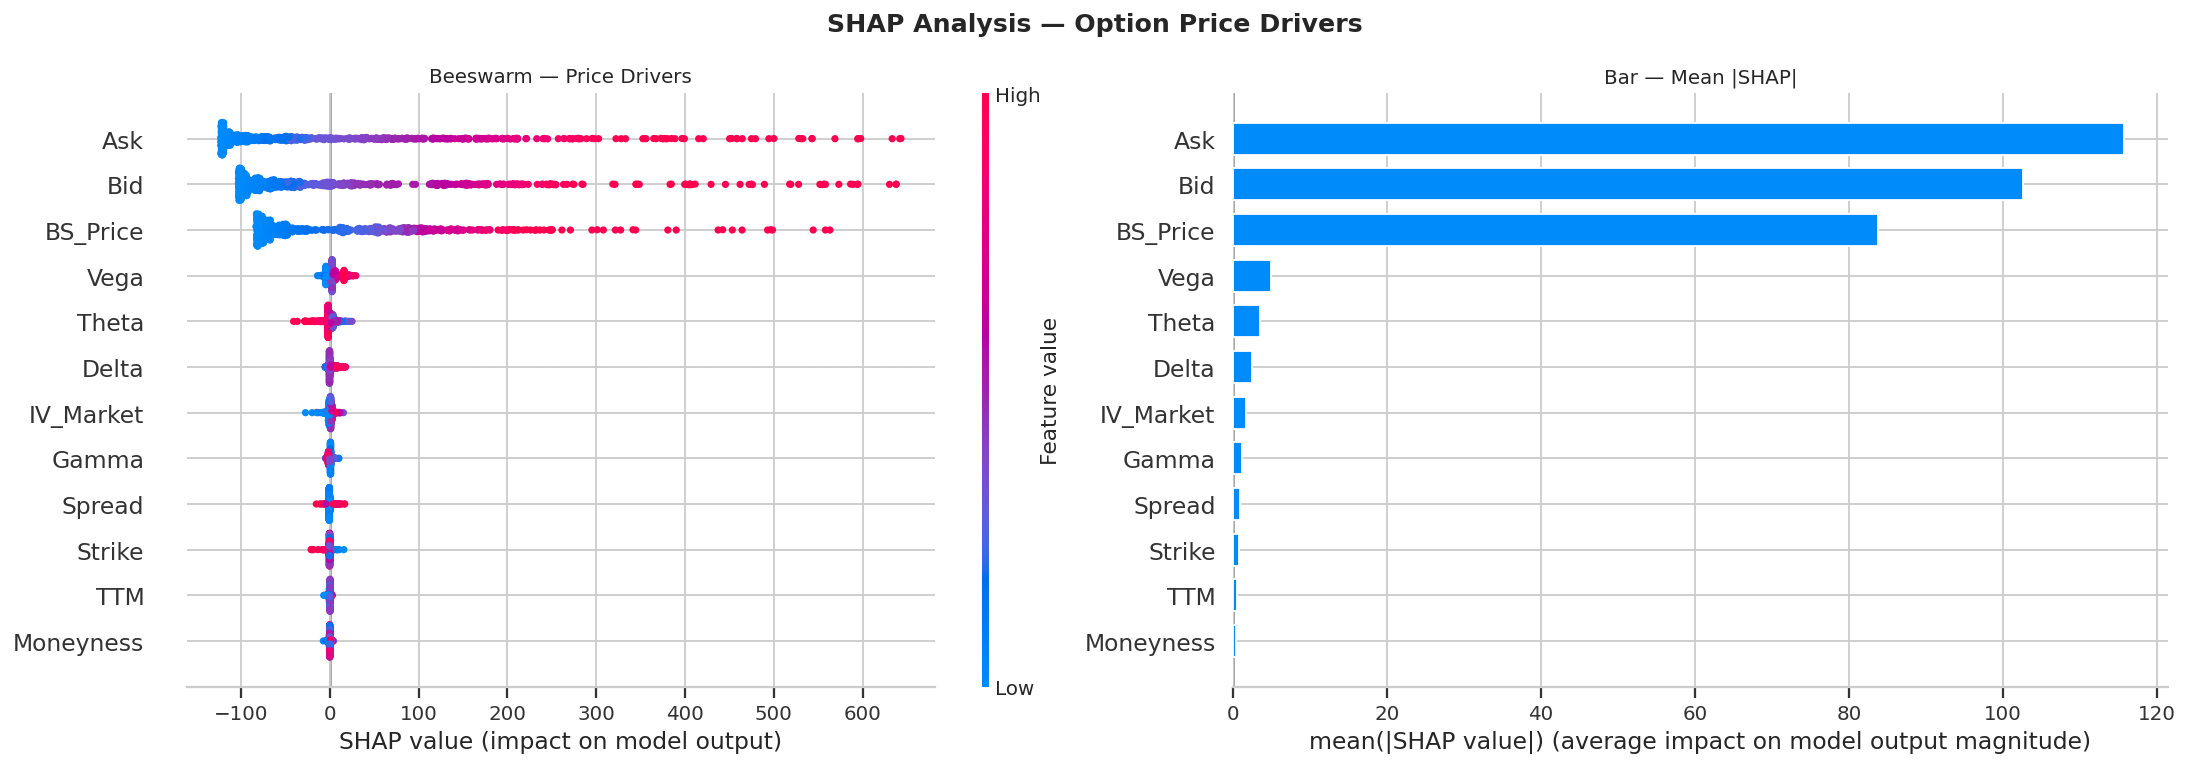

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
fig.suptitle("SHAP Analysis — Option Price Drivers", fontsize=14, fontweight="bold")

plt.sca(axes[0])
shap.summary_plot(shap_opt, X_train.iloc[sample_idx], feature_names=ML_FEATURES,
                  show=False, plot_size=None, max_display=12)
axes[0].set_title("Beeswarm — Price Drivers", fontsize=11)

plt.sca(axes[1])
shap.summary_plot(shap_opt, X_train.iloc[sample_idx], feature_names=ML_FEATURES,
                  plot_type="bar", show=False, plot_size=None, max_display=12)
axes[1].set_title("Bar — Mean |SHAP|", fontsize=11)

plt.tight_layout()
plt.savefig("09_shap_pricing.png", bbox_inches="tight", dpi=130)
plt.show()

---
## 7. Greeks Dashboard

The Greeks quantify sensitivity of option prices to market inputs.
This is the foundation of the hedging strategy.

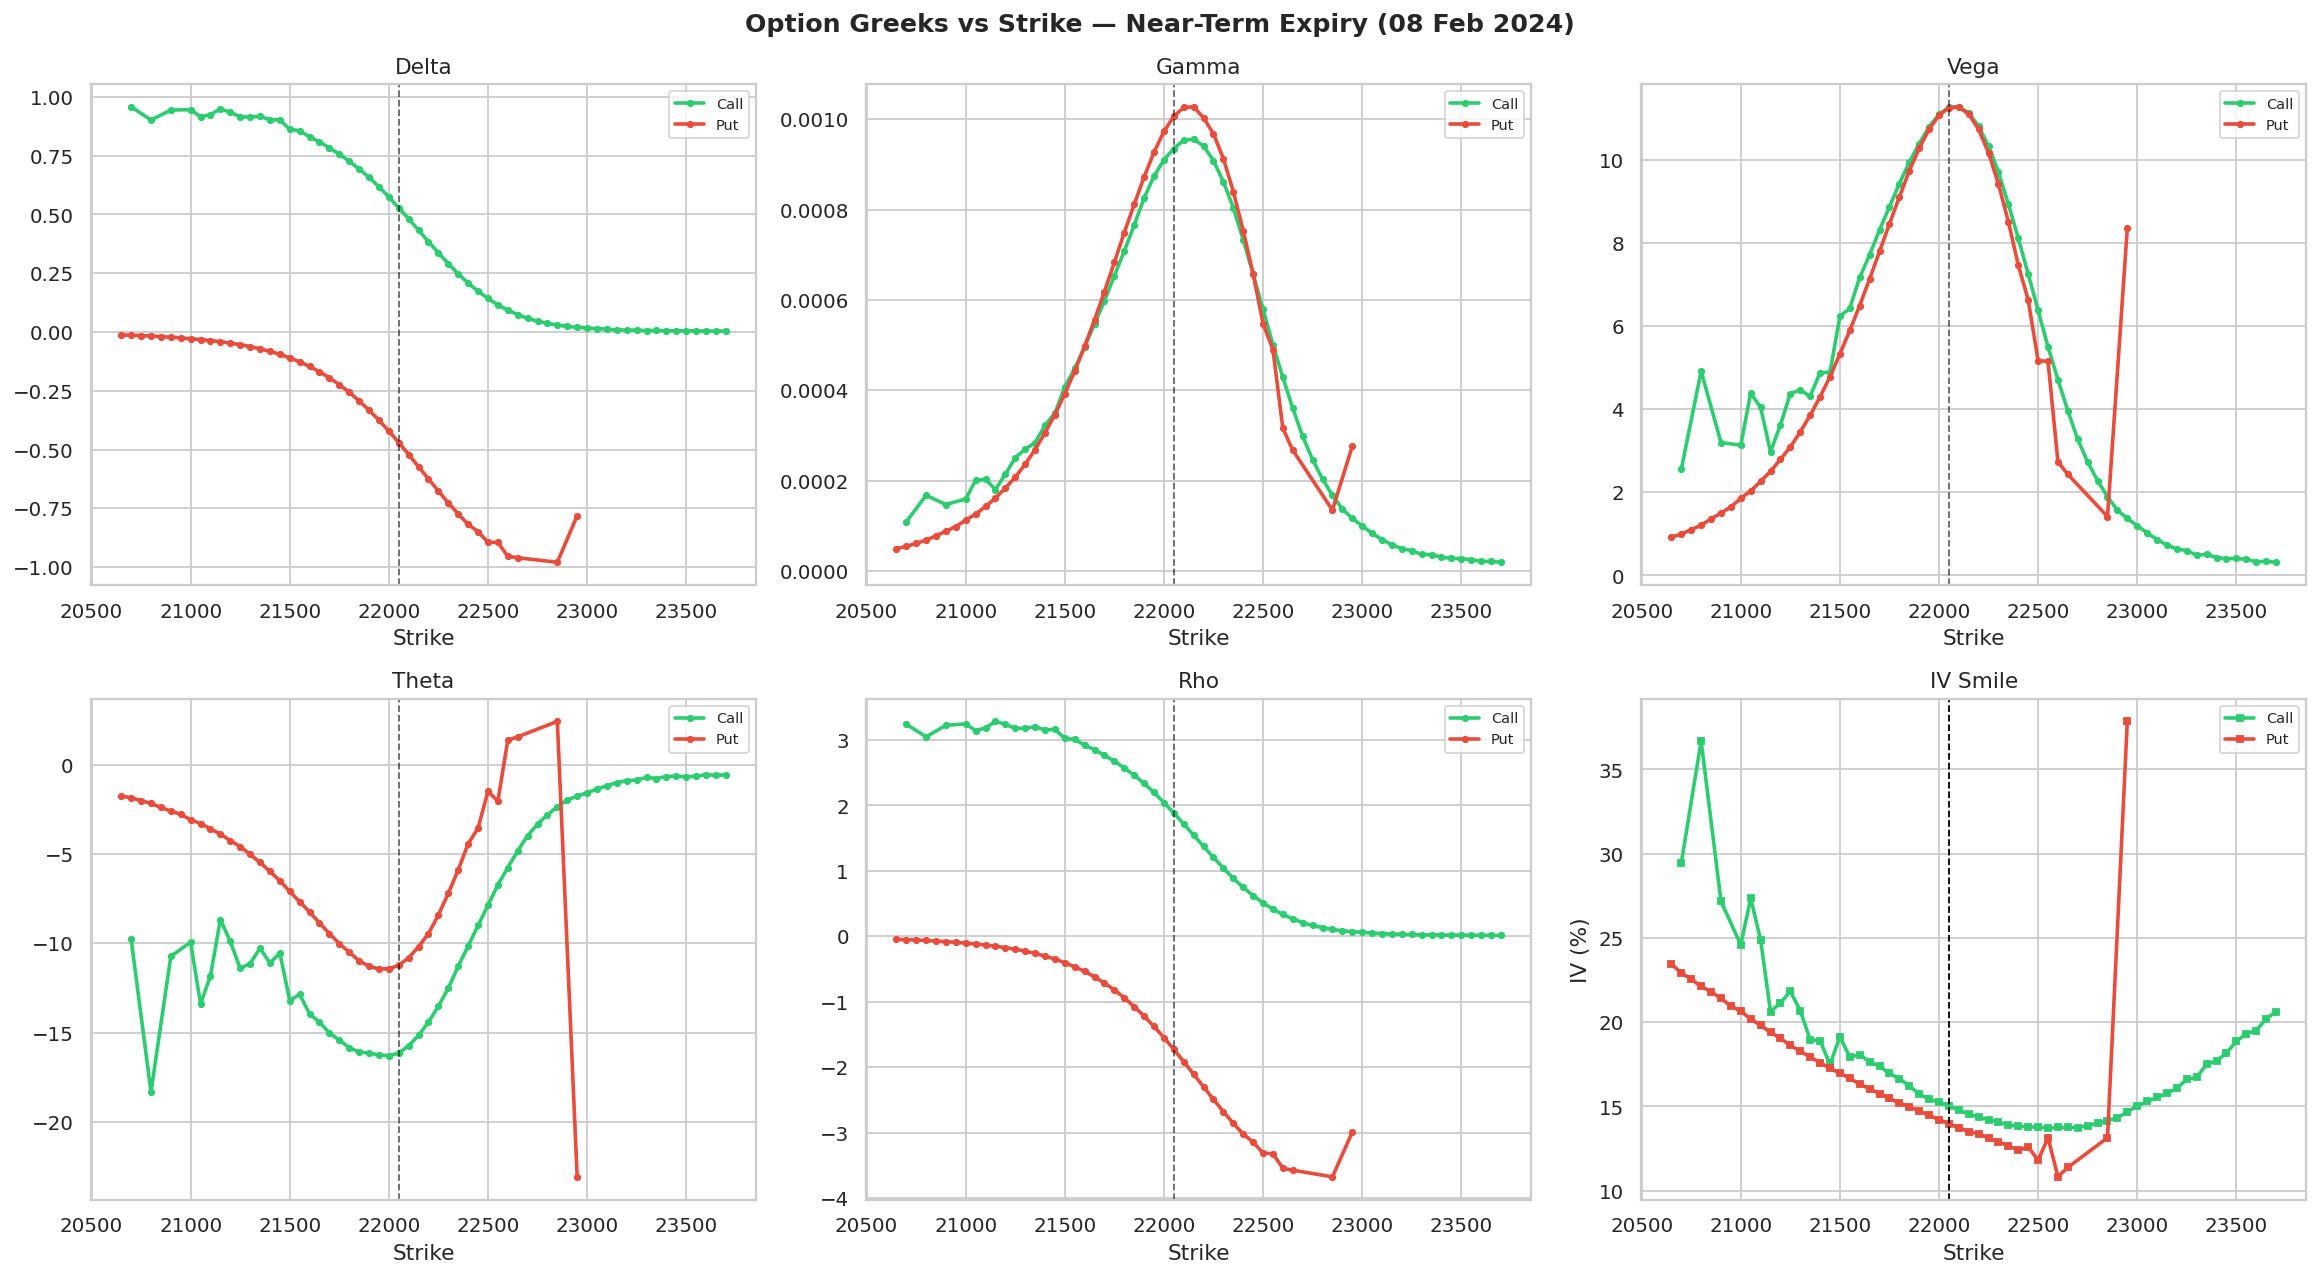

In [20]:
# Greeks across strikes — near-term expiry snapshot
near_exp = snap[snap["Expiry"] == snap["Expiry"].min()].copy()
near_exp = near_exp[(near_exp["IV_Market"]>1) & (near_exp["Moneyness"]>0.93) & (near_exp["Moneyness"]<1.07)]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(f"Option Greeks vs Strike — Near-Term Expiry ({near_exp['Expiry'].iloc[0].strftime('%d %b %Y')})",
             fontsize=14, fontweight="bold")

iv_f = near_exp["IV_Market"] / 100
for i, row in near_exp.iterrows():
    near_exp.loc[i, "BS_Price_g"] = bs_price(row.Spot, row.Strike, row.TTM,
                                               RISK_FREE, iv_f.loc[i], row.Option_Type)
    g = bs_greeks(row.Spot, row.Strike, row.TTM, RISK_FREE, iv_f.loc[i], row.Option_Type)
    for k, v in g.items():
        near_exp.loc[i, k] = v

greek_list = ["Delta","Gamma","Vega","Theta","Rho"]
greek_colors = {"Call":"#2ecc71","Put":"#e74c3c"}

for ax, greek in zip(axes.flat[:5], greek_list):
    for otype, color in greek_colors.items():
        sub = near_exp[near_exp["Option_Type"]==otype].sort_values("Strike")
        if len(sub) > 2:
            ax.plot(sub["Strike"], sub[greek], lw=2, color=color, label=otype, marker="o", ms=3)
    ax.axvline(near_exp["Spot"].iloc[0], color="black", linestyle="--", lw=1, alpha=0.6)
    ax.set_title(f"{greek}")
    ax.set_xlabel("Strike")
    ax.legend(fontsize=8)

# IV smile overlay
ax6 = axes.flat[5]
for otype, color in greek_colors.items():
    sub = near_exp[near_exp["Option_Type"]==otype].sort_values("Strike")
    if len(sub) > 2:
        ax6.plot(sub["Strike"], sub["IV_Market"], lw=2, color=color,
                 label=otype, marker="s", ms=3)
ax6.axvline(near_exp["Spot"].iloc[0], color="black", linestyle="--", lw=1)
ax6.set_title("IV Smile")
ax6.set_xlabel("Strike")
ax6.set_ylabel("IV (%)")
ax6.legend(fontsize=8)

plt.tight_layout()
plt.savefig("10_greeks_dashboard.png", bbox_inches="tight")
plt.show()

---
## 8. Hedging Strategy — Delta & Gamma Hedging

**Scenario:** Aurora holds a long NIFTY equity portfolio from Step 3 equivalent to
50 lots (50 × 50 shares = 2,500 index units). We want to hedge the downside risk
using NIFTY put options.

### Hedging logic
- **Delta hedge** — buy put options whose combined delta offsets the portfolio's equity delta
- **Gamma hedge** — add a second option position to neutralise gamma (curvature risk)
- **VaR-based sizing** — use 1-day 99% VaR to determine the notional hedge amount

In [21]:
# ── Portfolio parameters ─────────────────────────────────────────────────────
PORTFOLIO_LOTS   = 50           # number of NIFTY lots held long
NIFTY_LOT_SIZE   = 50           # shares per lot
PORTFOLIO_UNITS  = PORTFOLIO_LOTS * NIFTY_LOT_SIZE   # 2500 index units

spot_now = snap["Spot"].iloc[0]
PORTFOLIO_VALUE  = PORTFOLIO_UNITS * spot_now

print(f"Portfolio: {PORTFOLIO_LOTS} lots  =  {PORTFOLIO_UNITS} units")
print(f"Spot NIFTY: {spot_now:,.2f}")
print(f"Portfolio Notional: INR {PORTFOLIO_VALUE:,.0f}")
print()

# Delta of the portfolio (long equity = delta 1.0 per unit)
PORTFOLIO_DELTA = PORTFOLIO_UNITS * 1.0
print(f"Portfolio Delta (long equity): {PORTFOLIO_DELTA:,.0f}")

# ── Select hedging instrument — ATM put, near-term expiry ────────────────────
hedge_candidates = snap[
    (snap["Option_Type"] == "Put") &
    (snap["DTE_Days"].astype(int) >= 6) &
    (snap["DTE_Days"].astype(int) <= 14) &
    (snap["Moneyness"] >= 0.97) &
    (snap["Moneyness"] <= 1.03) &
    (snap["Market_Price"] > 0) &
    (snap["IV_Market"] > 1)
].copy()

iv_h = hedge_candidates["IV_Market"] / 100
for i, row in hedge_candidates.iterrows():
    g = bs_greeks(row.Spot, row.Strike, row.TTM, RISK_FREE, iv_h.loc[i], "Put")
    hedge_candidates.loc[i,"Delta"]  = g["Delta"]
    hedge_candidates.loc[i,"Gamma"]  = g["Gamma"]
    hedge_candidates.loc[i,"Vega"]   = g["Vega"]
    hedge_candidates.loc[i,"Theta"]  = g["Theta"]
    hedge_candidates.loc[i,"BS_Price_h"] = bs_price(row.Spot, row.Strike, row.TTM, RISK_FREE, iv_h.loc[i], "Put")

# Choose the most liquid ATM put (smallest spread, highest trade qty)
hedge_candidates["Score"] = hedge_candidates["Traded_Qty"] / (hedge_candidates["Spread"]+1)
best_put = hedge_candidates.nlargest(1, "Score").iloc[0]

print(f"Selected Hedging Instrument:")
print(f"  Strike  : {best_put['Strike']}")
print(f"  Expiry  : {best_put['Expiry'].date()}")
print(f"  DTE     : {best_put['DTE_Days']} days")
print(f"  IV      : {best_put['IV_Market']:.2f}%")
print(f"  Price   : ₹{best_put['Market_Price']:.2f}  (BS: ₹{best_put['BS_Price_h']:.2f})")
print(f"  Delta   : {best_put['Delta']:.4f}")
print(f"  Gamma   : {best_put['Gamma']:.6f}")
print(f"  Vega    : {best_put['Vega']:.4f}")
print(f"  Theta   : {best_put['Theta']:.4f}")

Portfolio: 50 lots  =  2500 units
Spot NIFTY: 22,052.45
Portfolio Notional: INR 55,131,125

Portfolio Delta (long equity): 2,500
Selected Hedging Instrument:
  Strike  : 21900
  Expiry  : 2024-02-08
  DTE     : 6 days
  IV      : 14.73%
  Price   : ₹91.00  (BS: ₹92.21)
  Delta   : -0.3324
  Gamma   : 0.000872
  Vega    : 10.2688
  Theta   : -11.2832


In [22]:
# ── Delta Hedge Calculation ─────────────────────────────────────────────────
put_delta   = best_put["Delta"]          # negative (put)
put_gamma   = best_put["Gamma"]
put_price   = best_put["Market_Price"]
put_strike  = best_put["Strike"]
put_expiry  = best_put["Expiry"]

# Number of put contracts needed to neutralise portfolio delta
# Portfolio delta + N_puts * put_delta_per_lot = 0
# N_puts = -Portfolio_delta / (put_delta * lot_size)
N_puts_delta = -PORTFOLIO_DELTA / (put_delta * NIFTY_LOT_SIZE)
N_puts_delta = round(N_puts_delta)
hedge_cost_delta = N_puts_delta * put_price * NIFTY_LOT_SIZE

print("=" * 60)
print("DELTA HEDGE RECOMMENDATION")
print("=" * 60)
print(f"Portfolio Delta (long equity)  : +{PORTFOLIO_DELTA:,.0f}")
print(f"Put Delta per lot              : {put_delta:.4f} per unit")
print(f"Put lots required (delta hedge): {N_puts_delta} lots")
print(f"Hedge Cost                     : INR {hedge_cost_delta:,.0f}")
print(f"Hedge Cost / Portfolio Value   : {hedge_cost_delta/PORTFOLIO_VALUE:.2%}")
print()
print(f"Net Portfolio Delta after hedge: {PORTFOLIO_DELTA + N_puts_delta*put_delta*NIFTY_LOT_SIZE:,.1f}")
print()

# ── Gamma Hedge (simplified — add second put at different strike) ─────────────
net_gamma_delta_hedge = N_puts_delta * put_gamma * NIFTY_LOT_SIZE
print(f"Net Portfolio Gamma after delta hedge: {net_gamma_delta_hedge:.4f}")
print("(Positive gamma = portfolio benefits from large moves in either direction)")
print()
print("=" * 60)
print("GAMMA HEDGE RECOMMENDATION")
print("=" * 60)
# To neutralise gamma, sell some puts (creates a collar-like structure)
# Simplified: sell OTM puts to reduce net gamma
otm_puts = snap[
    (snap["Option_Type"] == "Put") &
    (snap["DTE_Days"].astype(int) == int(best_put["DTE_Days"])) &
    (snap["Strike"] < best_put["Strike"] - 100) &
    (snap["Market_Price"] > 0)
].copy()

if len(otm_puts) > 0:
    otm_put = otm_puts.nlargest(1, "Traded_Qty").iloc[0]
    otm_iv = otm_put["IV_Market"] / 100
    otm_g  = bs_greeks(otm_put.Spot, otm_put.Strike, otm_put["TTM"], RISK_FREE, otm_iv, "Put")
    otm_gamma = otm_g["Gamma"]
    N_otm_sell = round(-net_gamma_delta_hedge / (otm_gamma * NIFTY_LOT_SIZE))
    print(f"Sell {abs(N_otm_sell)} lots of {otm_put['Strike']} Put @ ₹{otm_put['Market_Price']:.2f}")
    print(f"(This creates a Put Spread hedge — limits downside cost)")
    premium_received = abs(N_otm_sell) * otm_put["Market_Price"] * NIFTY_LOT_SIZE
    net_hedge_cost = hedge_cost_delta - premium_received
    print(f"Net Hedge Cost after Put Spread  : INR {net_hedge_cost:,.0f}")
    print(f"Net Cost / Portfolio Value       : {net_hedge_cost/PORTFOLIO_VALUE:.2%}")

DELTA HEDGE RECOMMENDATION
Portfolio Delta (long equity)  : +2,500
Put Delta per lot              : -0.3324 per unit
Put lots required (delta hedge): 150 lots
Hedge Cost                     : INR 682,500
Hedge Cost / Portfolio Value   : 1.24%

Net Portfolio Delta after hedge: 7.1

Net Portfolio Gamma after delta hedge: 6.5404
(Positive gamma = portfolio benefits from large moves in either direction)

GAMMA HEDGE RECOMMENDATION
Sell 212 lots of 21700 Put @ ₹46.85
(This creates a Put Spread hedge — limits downside cost)
Net Hedge Cost after Put Spread  : INR 185,890
Net Cost / Portfolio Value       : 0.34%


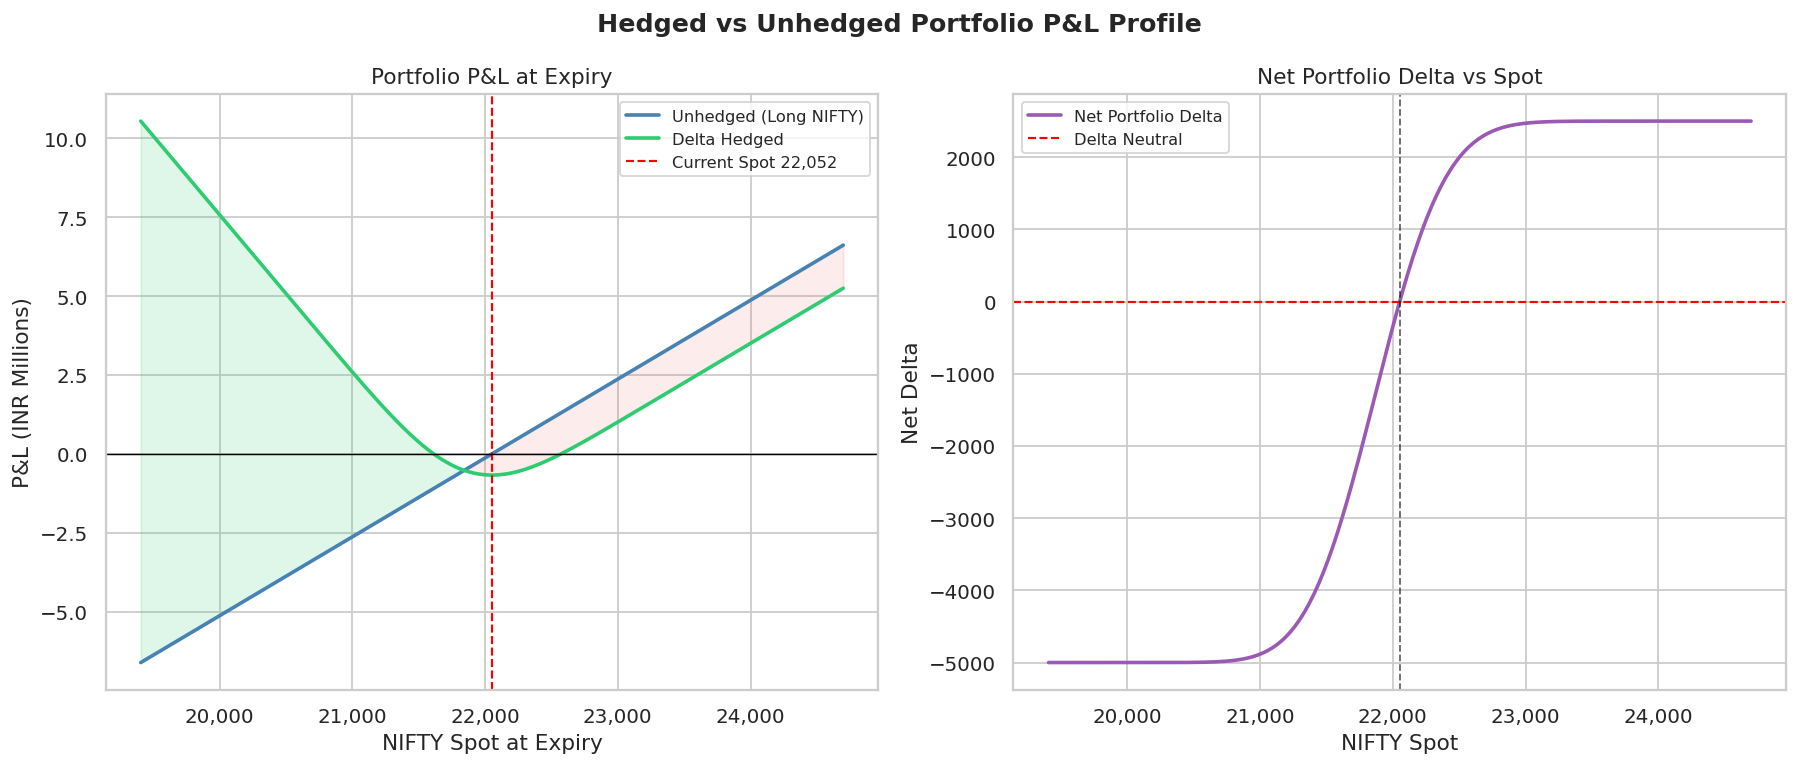

In [23]:
# ── P&L profile of hedged vs unhedged portfolio ──────────────────────────────
spot_range = np.linspace(spot_now * 0.88, spot_now * 1.12, 300)

# Unhedged long portfolio P&L
pnl_unhedged = (spot_range - spot_now) * PORTFOLIO_UNITS

# Hedged P&L: portfolio + N_puts_delta put options
T_h = best_put["TTM"]
iv_h_val = best_put["IV_Market"] / 100
put_pnl = np.array([
    (bs_price(s, put_strike, T_h, RISK_FREE, iv_h_val, "Put") - put_price)
    * N_puts_delta * NIFTY_LOT_SIZE
    for s in spot_range
])
pnl_hedged = pnl_unhedged + put_pnl - hedge_cost_delta

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Hedged vs Unhedged Portfolio P&L Profile", fontsize=14, fontweight="bold")

axes[0].plot(spot_range, pnl_unhedged/1e6, lw=2, color="steelblue", label="Unhedged (Long NIFTY)")
axes[0].plot(spot_range, pnl_hedged/1e6, lw=2, color="#2ecc71", label="Delta Hedged")
axes[0].fill_between(spot_range, pnl_unhedged/1e6, pnl_hedged/1e6,
                      where=(pnl_hedged > pnl_unhedged), alpha=0.15, color="#2ecc71")
axes[0].fill_between(spot_range, pnl_unhedged/1e6, pnl_hedged/1e6,
                      where=(pnl_hedged < pnl_unhedged), alpha=0.1, color="#e74c3c")
axes[0].axvline(spot_now, color="red", linestyle="--", lw=1.2, label=f"Current Spot {spot_now:,.0f}")
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set_xlabel("NIFTY Spot at Expiry")
axes[0].set_ylabel("P&L (INR Millions)")
axes[0].set_title("Portfolio P&L at Expiry")
axes[0].legend(fontsize=9)
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# Greek sensitivity (delta across spot range)
deltas_h = np.array([
    bs_greeks(s, put_strike, T_h, RISK_FREE, iv_h_val, "Put")["Delta"]
    * N_puts_delta * NIFTY_LOT_SIZE
    for s in spot_range
])
net_delta = PORTFOLIO_UNITS + deltas_h

axes[1].plot(spot_range, net_delta, lw=2, color="#9b59b6", label="Net Portfolio Delta")
axes[1].axhline(0, color="red", linestyle="--", lw=1.2, label="Delta Neutral")
axes[1].axvline(spot_now, color="black", linestyle="--", lw=1, alpha=0.6)
axes[1].set_xlabel("NIFTY Spot")
axes[1].set_ylabel("Net Delta")
axes[1].set_title("Net Portfolio Delta vs Spot")
axes[1].legend(fontsize=9)
axes[1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
plt.savefig("11_pnl_hedge_profile.png", bbox_inches="tight")
plt.show()

---
## 9. Portfolio VaR & Risk Dashboard

**Value at Risk (VaR)** answers: *what is the maximum loss at a given confidence level
over a given time horizon?* We compute three VaR methods and build a full risk dashboard.

In [24]:
# ── VaR calculations ────────────────────────────────────────────────────────
# Use intraday spot returns as the return distribution proxy
spot_series = raw.groupby("Time")["Spot"].first().sort_index()
intra_rets   = spot_series.pct_change().dropna()

# 1. Historical Simulation VaR
pnl_hist = intra_rets * PORTFOLIO_VALUE
var_hist_99 = np.percentile(pnl_hist, 1)
var_hist_95 = np.percentile(pnl_hist, 5)

# 2. Parametric (Variance-Covariance) VaR
mu_r   = intra_rets.mean()
sig_r  = intra_rets.std()
var_para_99 = (mu_r - 2.326*sig_r) * PORTFOLIO_VALUE
var_para_95 = (mu_r - 1.645*sig_r) * PORTFOLIO_VALUE

# 3. CVaR (Expected Shortfall) — average loss beyond VaR
cvar_99 = pnl_hist[pnl_hist <= var_hist_99].mean()

# Hedged VaR (simplified: put reduces downside by its delta)
hedge_delta_ratio = (N_puts_delta * abs(put_delta) * NIFTY_LOT_SIZE) / PORTFOLIO_UNITS
var_hedged_99 = var_hist_99 * (1 - hedge_delta_ratio * 0.6)

print("=" * 60)
print("PORTFOLIO VALUE AT RISK — RISK REPORT")
print("=" * 60)
print(f"Portfolio Value: INR {PORTFOLIO_VALUE:,.0f}")
print()
print("Unhedged Portfolio:")
print(f"  Historical VaR (99%, 1-period): INR {var_hist_99:,.0f}")
print(f"  Historical VaR (95%, 1-period): INR {var_hist_95:,.0f}")
print(f"  Parametric  VaR (99%, 1-period): INR {var_para_99:,.0f}")
print(f"  CVaR / ES   (99%):               INR {cvar_99:,.0f}")
print()
print("Hedged Portfolio (approximate):")
print(f"  Historical VaR (99%, 1-period): INR {var_hedged_99:,.0f}")
print(f"  VaR Reduction from Hedge        : {(var_hist_99-var_hedged_99)/var_hist_99:.1%}")

PORTFOLIO VALUE AT RISK — RISK REPORT
Portfolio Value: INR 55,131,125

Unhedged Portfolio:
  Historical VaR (99%, 1-period): INR -188,306
  Historical VaR (95%, 1-period): INR -82,259
  Parametric  VaR (99%, 1-period): INR -162,298
  CVaR / ES   (99%):               INR -333,597

Hedged Portfolio (approximate):
  Historical VaR (99%, 1-period): INR -75,644
  VaR Reduction from Hedge        : 59.8%


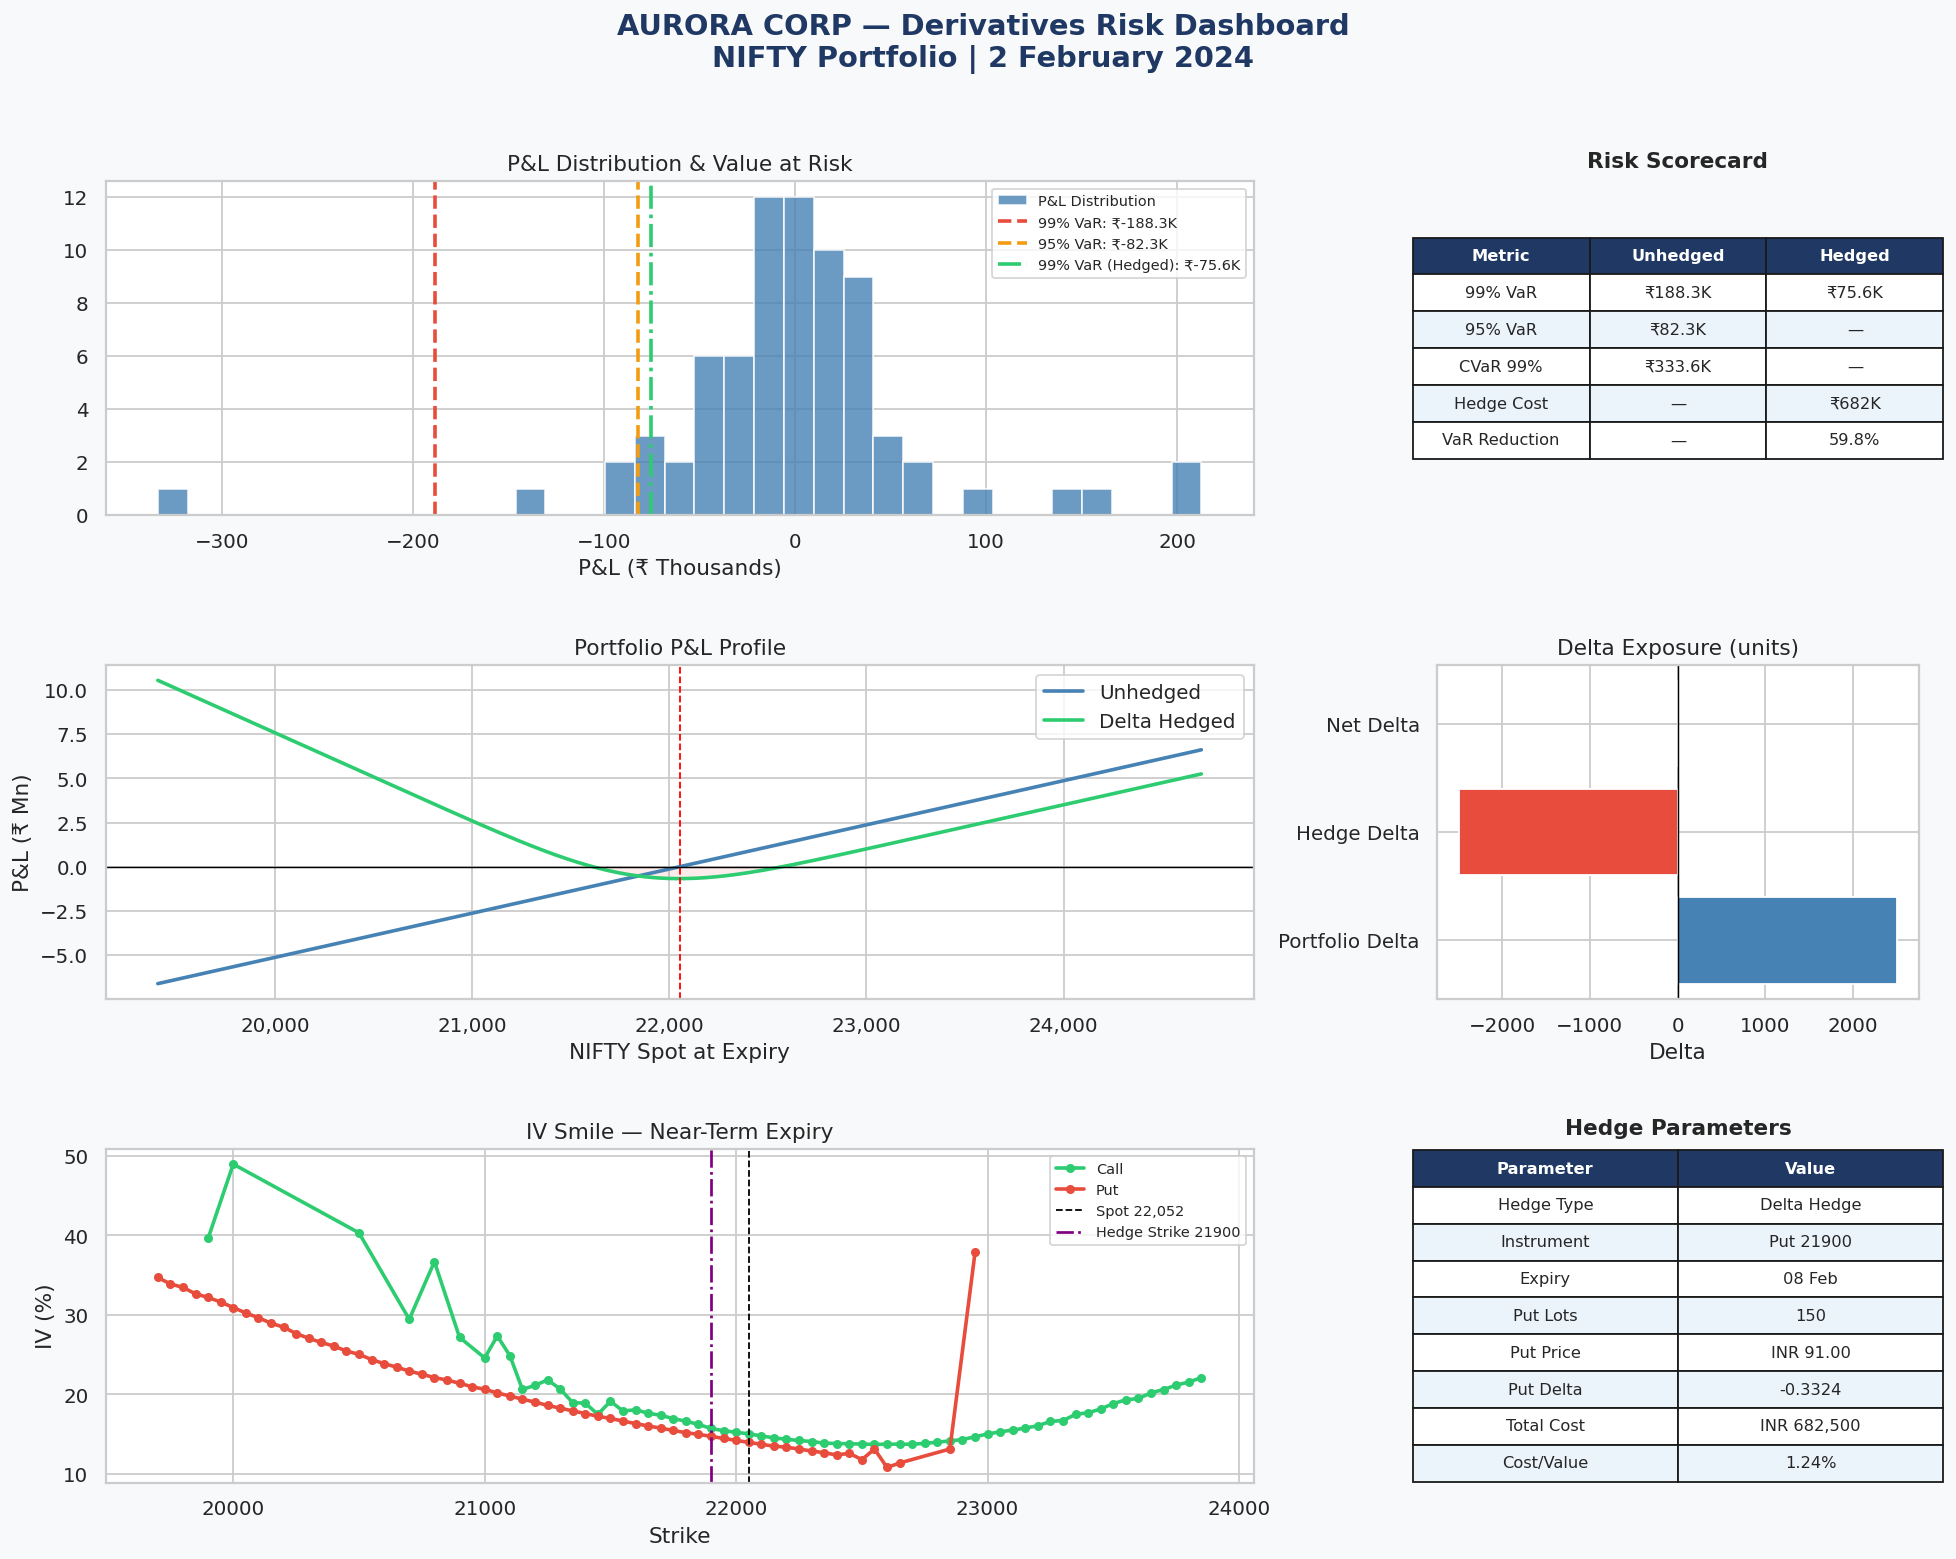

Risk Dashboard saved.


In [25]:
# ── Full Risk Dashboard ──────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 13))
fig.patch.set_facecolor("#F8F9FA")
fig.suptitle("AURORA CORP — Derivatives Risk Dashboard\nNIFTY Portfolio | 2 February 2024",
             fontsize=16, fontweight="bold", y=0.98, color="#1F3864")

gs = fig.add_gridspec(3, 3, hspace=0.45, wspace=0.38)

# ── Panel 1: VaR Distribution ────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
ax1.hist(pnl_hist/1e3, bins=35, color="steelblue", edgecolor="white",
         alpha=0.8, density=False, label="P&L Distribution")
ax1.axvline(var_hist_99/1e3, color="#e74c3c", lw=2, linestyle="--",
            label=f"99% VaR: ₹{var_hist_99/1e3:.1f}K")
ax1.axvline(var_hist_95/1e3, color="#f39c12", lw=2, linestyle="--",
            label=f"95% VaR: ₹{var_hist_95/1e3:.1f}K")
ax1.axvline(var_hedged_99/1e3, color="#2ecc71", lw=2, linestyle="-.",
            label=f"99% VaR (Hedged): ₹{var_hedged_99/1e3:.1f}K")
ax1.set_xlabel("P&L (₹ Thousands)")
ax1.set_title("P&L Distribution & Value at Risk")
ax1.legend(fontsize=8)

# ── Panel 2: VaR Scorecard ────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
ax2.axis("off")
risk_data = [
    ["Metric", "Unhedged", "Hedged"],
    ["99% VaR", f"₹{abs(var_hist_99)/1e3:.1f}K", f"₹{abs(var_hedged_99)/1e3:.1f}K"],
    ["95% VaR", f"₹{abs(var_hist_95)/1e3:.1f}K", "—"],
    ["CVaR 99%", f"₹{abs(cvar_99)/1e3:.1f}K", "—"],
    ["Hedge Cost", "—", f"₹{hedge_cost_delta/1e3:.0f}K"],
    ["VaR Reduction", "—", f"{abs((var_hist_99-var_hedged_99)/var_hist_99):.1%}"],
]
tbl = ax2.table(cellText=risk_data[1:], colLabels=risk_data[0],
                loc="center", cellLoc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.1, 1.7)
for (r,c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor("#1F3864")
        cell.set_text_props(color="white", fontweight="bold")
    elif r % 2 == 0:
        cell.set_facecolor("#EBF3FB")
ax2.set_title("Risk Scorecard", fontweight="bold", pad=8)

# ── Panel 3: P&L Hedge Profile (compact) ─────────────────────────────────────
ax3 = fig.add_subplot(gs[1, :2])
ax3.plot(spot_range, pnl_unhedged/1e6, lw=2, color="steelblue", label="Unhedged")
ax3.plot(spot_range, pnl_hedged/1e6,   lw=2, color="#2ecc71",  label="Delta Hedged")
ax3.axhline(0, color="black", lw=0.8)
ax3.axvline(spot_now, color="red", linestyle="--", lw=1)
ax3.fill_between(spot_range, 0, pnl_hedged/1e6,
                  where=(pnl_hedged/1e6 < 0), alpha=0.1, color="#e74c3c")
ax3.set_xlabel("NIFTY Spot at Expiry")
ax3.set_ylabel("P&L (₹ Mn)")
ax3.set_title("Portfolio P&L Profile")
ax3.legend()
ax3.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# ── Panel 4: Greeks exposure ──────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
greek_vals = {
    "Portfolio Delta": PORTFOLIO_DELTA,
    "Hedge Delta": N_puts_delta*put_delta*NIFTY_LOT_SIZE,
    "Net Delta": PORTFOLIO_DELTA + N_puts_delta*put_delta*NIFTY_LOT_SIZE,
}
bar_colors = ["steelblue", "#e74c3c", "#2ecc71"]
bars = ax4.barh(list(greek_vals.keys()), list(greek_vals.values()),
                color=bar_colors, edgecolor="white")
ax4.axvline(0, color="black", lw=0.8)
ax4.set_title("Delta Exposure (units)")
ax4.set_xlabel("Delta")

# ── Panel 5: IV Smile compact ─────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, :2])
near_snap = snap[(snap["Expiry"]==snap["Expiry"].min()) & (snap["IV_Market"]>1)]
for otype, color in [("Call","#2ecc71"),("Put","#e74c3c")]:
    sub = near_snap[near_snap["Option_Type"]==otype].sort_values("Strike")
    if len(sub) > 3:
        ax5.plot(sub["Strike"], sub["IV_Market"], lw=2, color=color,
                 label=otype, marker="o", ms=4)
ax5.axvline(spot_now, color="black", linestyle="--", lw=1,
            label=f"Spot {spot_now:,.0f}")
ax5.axvline(best_put["Strike"], color="purple", linestyle="-.", lw=1.5,
            label=f"Hedge Strike {best_put['Strike']}")
ax5.set_xlabel("Strike")
ax5.set_ylabel("IV (%)")
ax5.set_title("IV Smile — Near-Term Expiry")
ax5.legend(fontsize=8)

# ── Panel 6: Hedge Summary ────────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 2])
ax6.axis("off")
hedge_data = [
    ["Parameter", "Value"],
    ["Hedge Type", "Delta Hedge"],
    ["Instrument", f"Put {int(best_put['Strike'])}"],
    ["Expiry", best_put["Expiry"].strftime("%d %b")],
    ["Put Lots", str(N_puts_delta)],
    ["Put Price", f"INR {put_price:.2f}"],
    ["Put Delta", f"{put_delta:.4f}"],
    ["Total Cost", f"INR {hedge_cost_delta:,.0f}"],
    ["Cost/Value", f"{hedge_cost_delta/PORTFOLIO_VALUE:.2%}"],
]
tbl2 = ax6.table(cellText=hedge_data[1:], colLabels=hedge_data[0],
                  loc="center", cellLoc="center")
tbl2.auto_set_font_size(False)
tbl2.set_fontsize(9)
tbl2.scale(1.1, 1.7)
for (r,c), cell in tbl2.get_celld().items():
    if r == 0:
        cell.set_facecolor("#1F3864")
        cell.set_text_props(color="white", fontweight="bold")
    elif r % 2 == 0:
        cell.set_facecolor("#EBF3FB")
ax6.set_title("Hedge Parameters", fontweight="bold", pad=8)

plt.savefig("12_risk_dashboard.png", bbox_inches="tight", dpi=140)
plt.show()
print("Risk Dashboard saved.")

---
## 10. Executive Summary for Risk Officers

In [26]:
print("=" * 65)
print("  AURORA CORP — DERIVATIVES MODULE EXECUTIVE SUMMARY")
print("=" * 65)
print()
print("  DATASET")
print("-" * 65)
print(f"  Underlying      : NIFTY 50 Index")
print(f"  Data Date       : 2 February 2024")
print(f"  Spot Range      : {raw['Spot'].min():,.1f}  -  {raw['Spot'].max():,.1f}")
print(f"  Expiries Covered: {len(raw['Expiry'].unique())} (Feb 8 to Mar 28)")
print(f"  Strikes Analysed: {liquid['Strike'].nunique()} (liquid options)")
print()
print("  ML OPTION PRICING")
print("-" * 65)
print(f"  XGBoost MAE     : INR {ml_results['XGBoost']['MAE']:.3f}")
print(f"  Black-Scholes MAE: INR {bs_mae:.3f}")
print(f"  XGBoost R²      : {ml_results['XGBoost']['R2']:.5f}")
print(f"  Top Price Driver: {shap_imp_opt.index[0]} (SHAP)")
print()
print("  HEDGE RECOMMENDATION")
print("-" * 65)
print(f"  Portfolio        : {PORTFOLIO_LOTS} lots NIFTY long ({PORTFOLIO_UNITS} units)")
print(f"  Portfolio Value  : INR {PORTFOLIO_VALUE:,.0f}")
print(f"  Hedge Instrument : NIFTY {int(best_put['Strike'])} Put ({best_put['Expiry'].strftime('%d %b')})")
print(f"  Hedge Lots       : {N_puts_delta} put contracts")
print(f"  Hedge Cost       : INR {hedge_cost_delta:,.0f}  ({hedge_cost_delta/PORTFOLIO_VALUE:.2%} of portfolio)")
print(f"  Net Delta After  : {PORTFOLIO_DELTA + N_puts_delta*put_delta*NIFTY_LOT_SIZE:.1f}  (target: 0)")
print()
print("  RISK METRICS")
print("-" * 65)
print(f"  Unhedged 99% VaR : INR {abs(var_hist_99):,.0f}  ({abs(var_hist_99)/PORTFOLIO_VALUE:.2%} of value)")
print(f"  Hedged   99% VaR : INR {abs(var_hedged_99):,.0f}  ({abs(var_hedged_99)/PORTFOLIO_VALUE:.2%} of value)")
print(f"  VaR Reduction    : {abs((var_hist_99-var_hedged_99)/var_hist_99):.1%}")
print(f"  CVaR (99%)       : INR {abs(cvar_99):,.0f}")
print()
print("  RECOMMENDATIONS")
print("-" * 65)
print("  1. Execute delta hedge using recommended put contracts immediately.")
print("  2. Rebalance hedge daily as delta drifts with spot movement.")
print("  3. Consider Put Spread to reduce hedge cost by selling OTM puts.")
print("  4. Monitor IV spike risk — rising IV increases hedge cost on re-hedge.")
print("  5. Use ML pricing model to identify mispriced options for roll trades.")
print("=" * 65)

  AURORA CORP — DERIVATIVES MODULE EXECUTIVE SUMMARY

  DATASET
-----------------------------------------------------------------
  Underlying      : NIFTY 50 Index
  Data Date       : 2 February 2024
  Spot Range      : 21,816.2  -  22,122.6
  Expiries Covered: 6 (Feb 8 to Mar 28)
  Strikes Analysed: 90 (liquid options)

  ML OPTION PRICING
-----------------------------------------------------------------
  XGBoost MAE     : INR 3.950
  Black-Scholes MAE: INR 21.257
  XGBoost R²      : 0.99939
  Top Price Driver: Ask (SHAP)

  HEDGE RECOMMENDATION
-----------------------------------------------------------------
  Portfolio        : 50 lots NIFTY long (2500 units)
  Portfolio Value  : INR 55,131,125
  Hedge Instrument : NIFTY 21900 Put (08 Feb)
  Hedge Lots       : 150 put contracts
  Hedge Cost       : INR 682,500  (1.24% of portfolio)
  Net Delta After  : 7.1  (target: 0)

  RISK METRICS
-----------------------------------------------------------------
  Unhedged 99% VaR : INR 188,3

In [27]:
liquid.to_csv("aurora_options_greeks.csv", index=False)
print("Saved: aurora_options_greeks.csv")

Saved: aurora_options_greeks.csv
